In [ ]:
%pip install xgboost lightgbm catboost optuna astropy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.8 MB/s eta 0:00:00


Importazione librerie

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis, zscore
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from numpy.fft import rfft, rfftfreq

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    f1_score, classification_report, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

import tensorflow as tf
from keras.models import Sequential, Model, load_model
from keras.layers import (
    Input, Conv1D, MaxPooling1D, Flatten, Dense,
    LSTM, GRU, Bidirectional, Dropout, BatchNormalization,
    Average, Concatenate
)
from keras.optimizers import Adam, SGD
from keras.losses import BinaryCrossentropy
from keras.metrics import FBetaScore, AUC as KerasAUC
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import kagglehub
from astropy.stats import sigma_clip

Caricamento dataset

In [ ]:
path_dataset = kagglehub.dataset_download("keplersmachines/kepler-labelled-time-series-data")
print("Path dataset:", path_dataset)

folders = sorted(os.listdir(path_dataset))
for f in folders:
    print(f)

csTrain = pd.read_csv(os.path.join(path_dataset, folders[1]))
csTest  = pd.read_csv(os.path.join(path_dataset, folders[0]))

print(f"\nTrain shape: {csTrain.shape}")
print(f"Test  shape: {csTest.shape}")
print(f"\nDistribuzione label TRAIN:\n{csTrain['LABEL'].value_counts()}")
print(f"\nDistribuzione label TEST:\n{csTest['LABEL'].value_counts()}")

100%|██████████| 55.9M/55.9M [00:00<00:00, 99.2MB/s]

Extracting files...


Path dataset: /root/.cache/kagglehub/datasets/keplersmachines/kepler-labelled-time-series-data/versions/3
exoTest.csv
exoTrain.csv

Train shape: (5087, 3198)
Test  shape: (570, 3198)

Distribuzione label TRAIN:
LABEL
1    5050
2      37
Name: count, dtype: int64

Distribuzione label TEST:
LABEL
1    565
2      5
Name: count, dtype: int64


La directory scaricata contiene esclusivamente due file, corrispondenti rispettivamente al dataset di Training e a quello di Test. In base alla descrizione ufficiale presente su Kaggle, i dati presentano le seguenti caratteristiche:Train dataset: è costituito da 5.087 righe (osservazioni distinte), ciascuna delle quali presenta 3.198 colonne.Test dataset: ha la medesima struttura del set di allenamento, ma è composto da 570 osservazioni.L'obiettivo è addestrare un algoritmo di Machine Learning o una rete neurale profonda (DNN) a riconoscere, tramite la variazione del flusso luminoso stellare nel tempo, se il calo di intensità sia dovuto al transito di un esopianeta in orbita o ad altri fattori di variabilità.I valori temporali del flusso fotometrico sono contenuti nelle colonne dalla 2 alla 3.198. La prima colonna, invece, funge da etichetta (label): il valore 2 indica la presenza confermata di almeno un esopianeta (37 campioni nel Train dataset e 5 nel Test dataset), mentre il valore 1 indica che la variazione è legata ad altri fattori (5.050 campioni nel Train dataset e 565 nel Test dataset). Si sottolinea che alcune stelle potrebbero ospitare sistemi multi-planetari, mostrando quindi cali di flusso multipli e periodici nel tempo.I dati sono stati pre-elaborati e derivano dalle osservazioni del telescopio spaziale Kepler della NASA. Più del 99% di questo specifico dataset proviene dalla Campagna 3 di osservazione (conclusasi nell'estate 2016), scelta poiché ritenuta ormai consolidata e priva di esopianeti non ancora catalogati, riducendo così il rischio di etichette errate. Per aumentare il bilanciamento e il numero di esopianeti confermati all'interno del dataset, sono stati inclusi anche sistemi planetari noti provenienti da altre campagne successive della missione (come la Campagna 12, i cui dati storici sono stati rilasciati a inizio 2017).

Dalla descrizione del dataset, dalla natura dei dati e dalla loro origine fisica, è possibile trarre indicazioni fondamentali sulla strategia ottimale da seguire per l'elaborazione dei dati e sui pattern visivi attesi (i segnali caratteristici della presenza di uno o più esopianeti):Modellazione sequenziale e temporale: Poiché le caratteristiche (feature) del dataset rappresentano l'evoluzione del flusso luminoso nel tempo (serie storiche), l'approccio architetturale richiede modelli in grado di catturare le dipendenze temporali. Accanto alle reti neurali ricorrenti come le LSTM (progettate per mantenere memoria degli istanti precedenti), una valida alternativa è rappresentata dalle reti convoluzionali monodimensionali (Conv1D), ideali per estrarre feature geometriche locali, come la forma e la profondità dei cali di luce, in modo computazionalmente più efficiente.Gestione del forte sbilanciamento (Imbalanced Dataset): Il numero di stelle con esopianeti confermati è estremamente ridotto rispetto alle altre. Questa forte asimmetria richiede l'adozione di strategie mirate, come il bilanciamento dei pesi delle classi nella funzione di perdita (Class Weights), tecniche di campionamento (oversampling o undersampling), o metriche di valutazione specifiche (Precision, Recall e F1-score) al posto della semplice accuratezza.Fisica del problema e dinamica del flusso stellare: Il flusso di radiazione emesso da una stella non è mai perfettamente costante. Anche su scale temporali brevi (giorni o mesi), le stelle mostrano una variabilità intrinseca dovuta a macchie stellari, brillamenti o pulsazioni. Di conseguenza, le variazioni di flusso osservate possono essere ricondotte principalmente a due scenari:Transito di esopianeti: Essendo i pianeti legati a orbite stabili e stazionarie, il calo di flusso luminoso deve presentarsi come un fenomeno strettamente periodico e con la medesima profondità a ogni transito. Nel caso di sistemi multi-planetari, la curva di luce mostrerà la sovrapposizione di più segnali periodici differenti. Il modello deve quindi essere in grado di rilevare queste periodicità multiple, distinguendole dal rumore di fondo.Variabilità stellare o anomalie strumentali: Fenomeni come l'attività magnetica della stella (macchie solari), il passaggio di polveri cosmiche o il rumore termico del telescopio generano cali di flusso che, in genere, non sono periodici o presentano profili asimmetrici e intensità variabili.Segnali sovrapposti: Nel caso in cui l'attività stellare o un'anomalia si sovrappongano temporalmente al transito di un pianeta, l'algoritmo deve essere sufficientemente robusto da isolare il segnale periodico del transito, dando maggiore rilevanza alla regolarità temporale dell'evento piuttosto che all'intensità assoluta del singolo calo.Infine, poiché le curve di luce reali sono spesso non stazionarie (presentano trend di lungo periodo dovuti al decadimento termico del telescopio o a cicli stellari), sarà fondamentale applicare una fase di pre-processing (come il detrending o lo scaling locale descritto in precedenza). Questo passaggio elimina i trend macroscopici e rende il segnale stazionario, permettendo ai filtri della rete neurale di concentrarsi esclusivamente sulla geometria dei transiti.

Visualizziamo quale è l'andamento dei dati con cui abbiamo a che fare e vedere se sono presenti outlier di qualsivoglia tipologia.

Le prime immagini mostrate di seguito sono relative ai dati raccolti su traiettorie con esopianeti

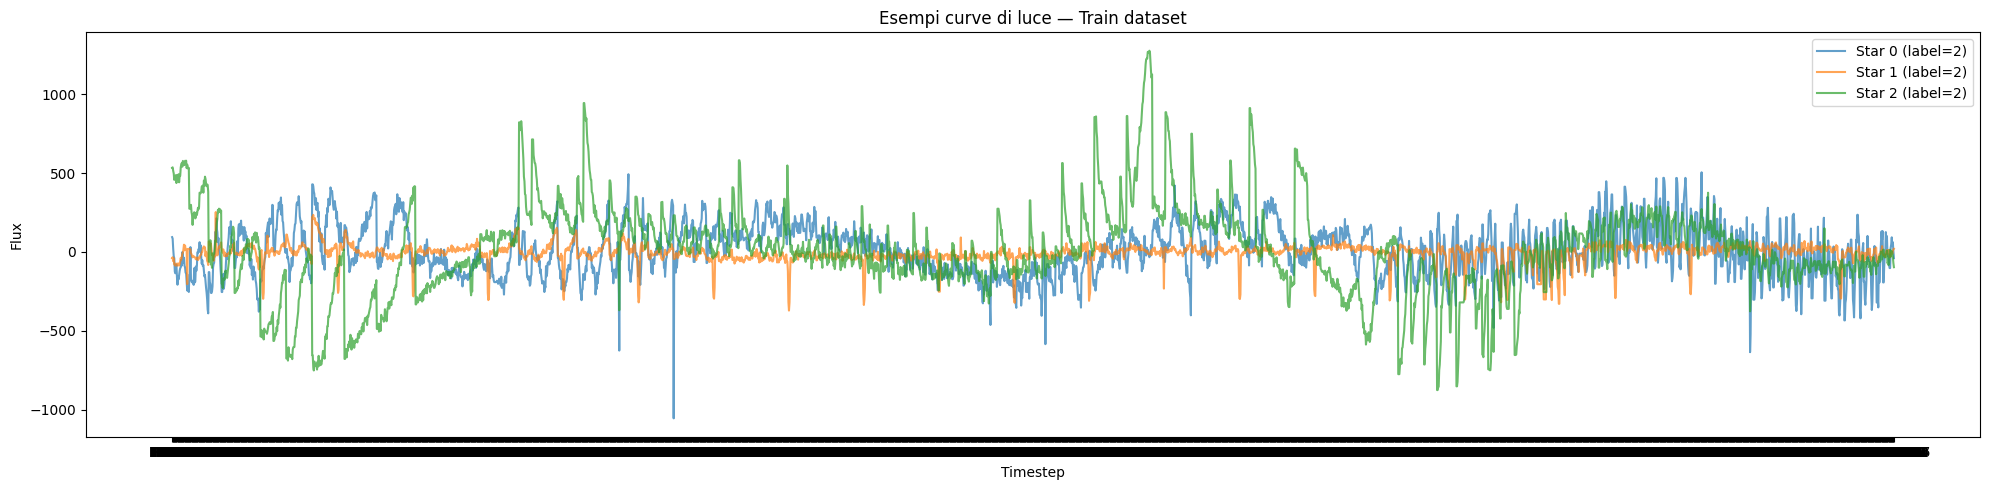

In [ ]:
plt.figure(figsize=(20, 5))
plt.title("Esempi curve di luce — Train dataset")
plt.xlabel("Timestep")
plt.ylabel("Flux")
for i in range(3):
    plt.plot(csTrain.iloc[i, 1:], alpha=0.7, label=f"Star {i} (label={csTrain.iloc[i,0]})")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
X_train_raw = csTrain.drop(columns=["LABEL"]).values.astype(np.float32)
y_train_raw = csTrain["LABEL"].values                     # valori: 1 o 2
X_test_raw  = csTest.drop(columns=["LABEL"]).values.astype(np.float32)
y_test_raw  = csTest["LABEL"].values

Conversione label a 0/1 da 1/2 presente nei dati originali. Questo è necessario per ridurre il numero di passaggi necessari ad
estrarre le previsioni fatte dal modello; infatti si usa come funzione di attivazione finale la sigmoide con trshold 0.5 che è una funzione $f(x): R → (0,1)$. Per tornare alla notazione originale eventualmente si può sommare 1 alle predizioni effettuate

In [ ]:
y_train_raw = y_train_raw - 1   # 0 = no pianeta, 1 = esopianeta
y_test_raw  = y_test_raw  - 1

n_timesteps = X_train_raw.shape[1]
tempo = np.arange(n_timesteps)

print(f"\nTimesteps per curva: {n_timesteps}")
print(f"Positivi (esopianeta) TRAIN: {y_train_raw.sum()} / {len(y_train_raw)}")
print(f"Positivi (esopianeta) TEST : {y_test_raw.sum()}  / {len(y_test_raw)}")


Timesteps per curva: 3197
Positivi (esopianeta) TRAIN: 37 / 5087
Positivi (esopianeta) TEST : 5  / 570


Dalla descrizione del dataset presente su Kaggle si scopre che i dati sono stati raccolti ogni 30 minuti per più di 4 anni. Questo significa che le previsioni possono essere falsate per il fatto che i dati contengono contemporaneamente sia le variazioni di luminosità cui siamo interessati ma anche informazioni relative la stella in sè( fluttuazioni date dall'attività stellare o dalla presenza di macchie stellari che si ripresentano periodicamente). Per estrarre solo le informazioni relative al passaggio di esopianeti abbiamo due possibilità:
* effettuare fit lineare su intervalli di durata $Δt$: ci consente di capire se ci sono variazioni importanti su larga scala  temporale
* utilizzare filtri di cui ci si serve in teoria dei segnali


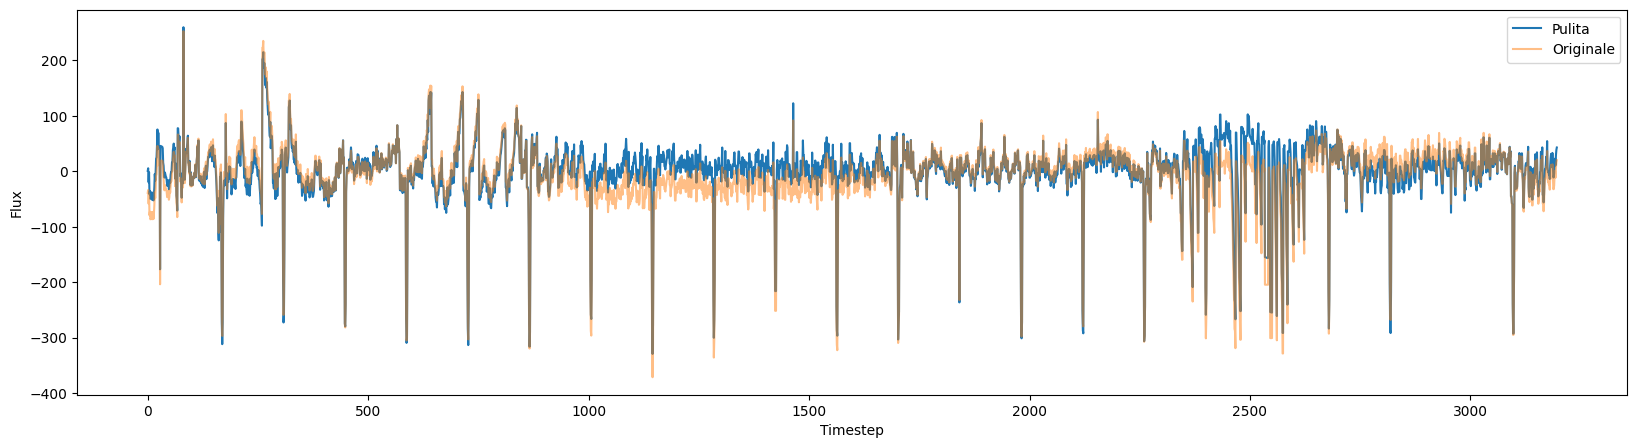

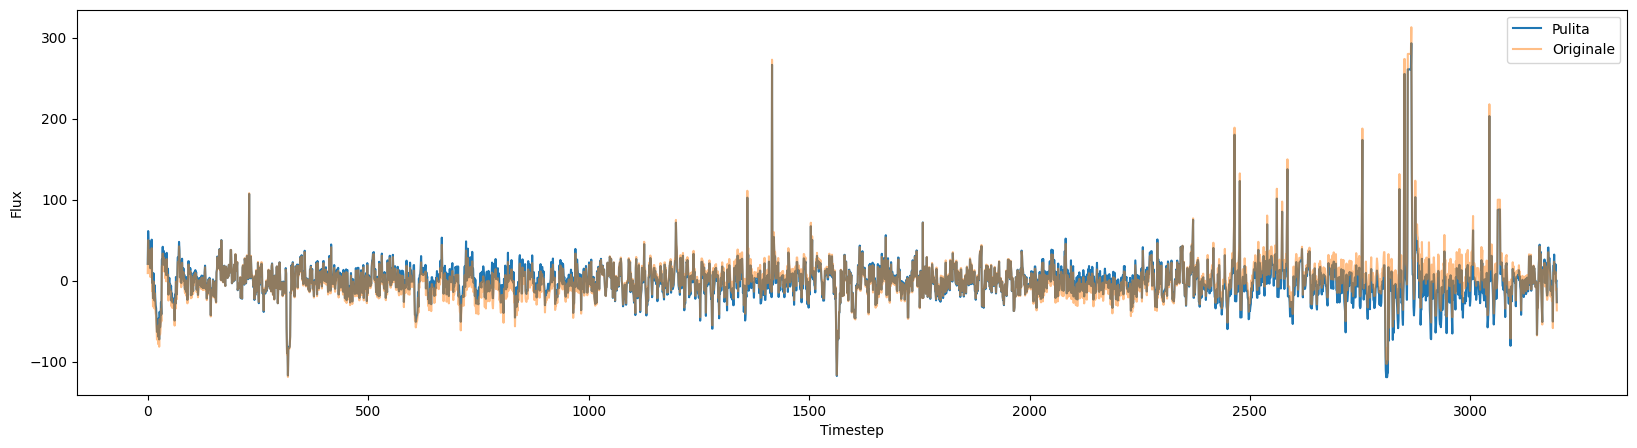

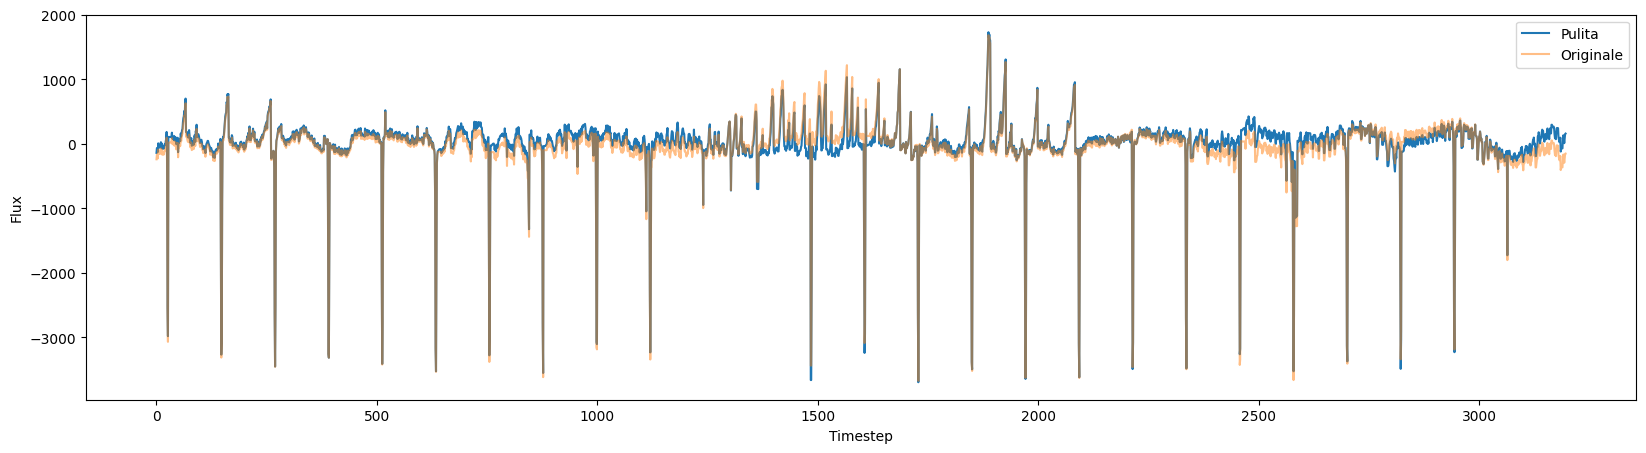

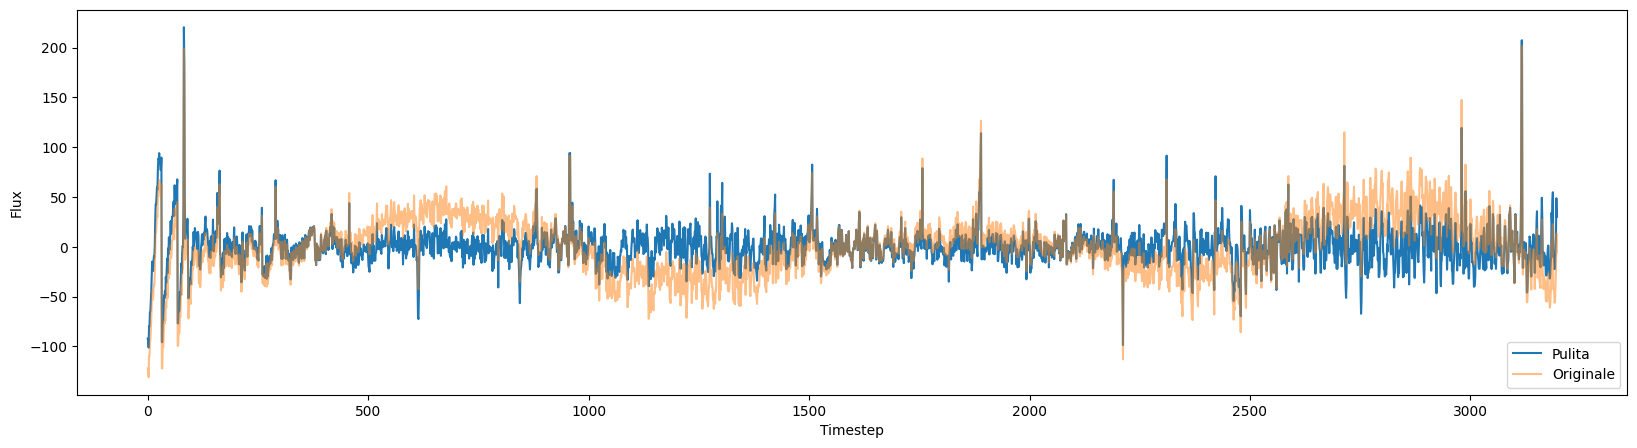

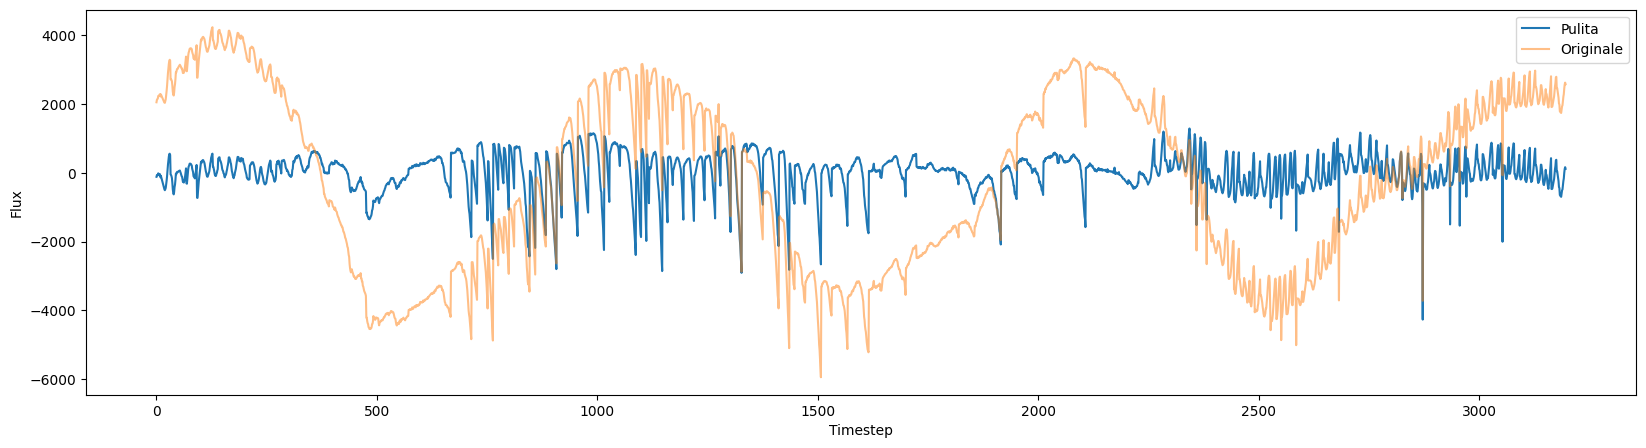

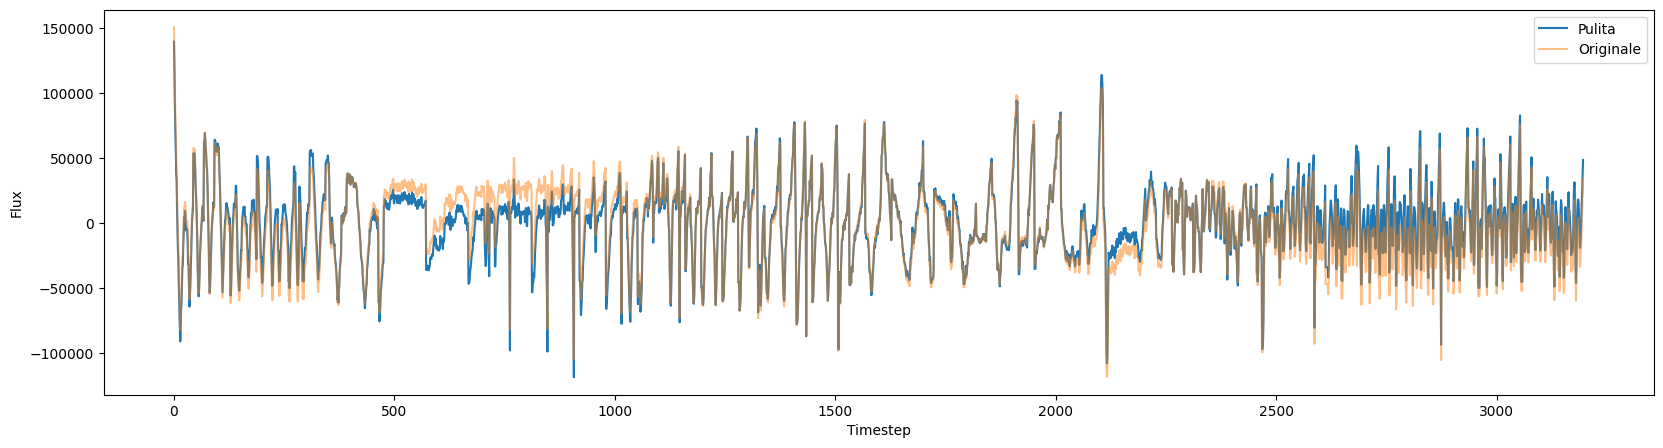

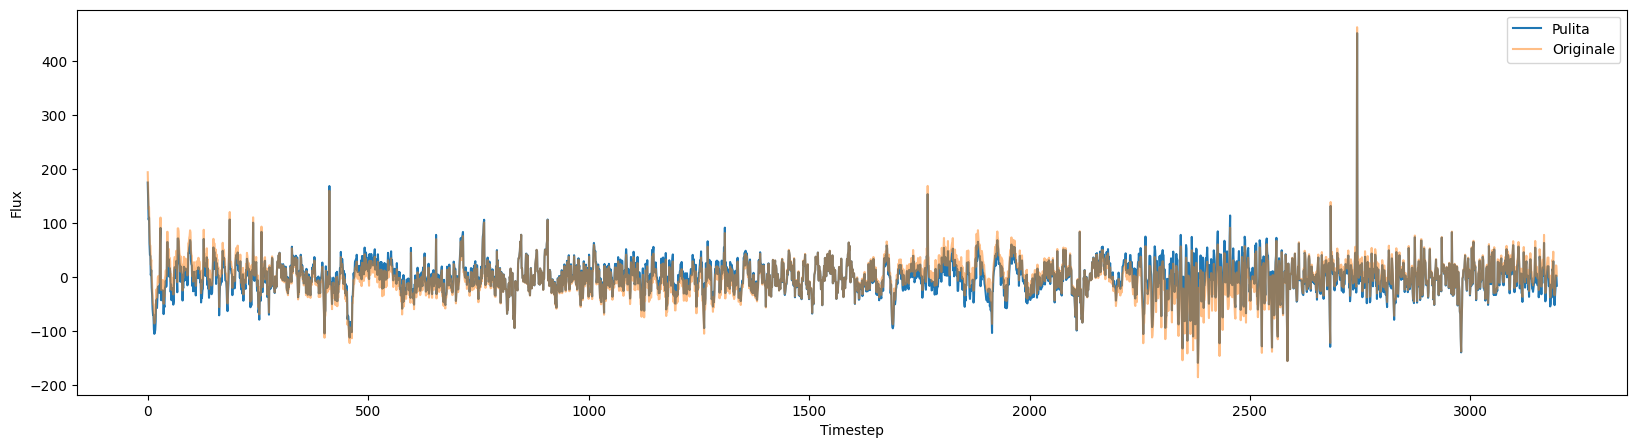

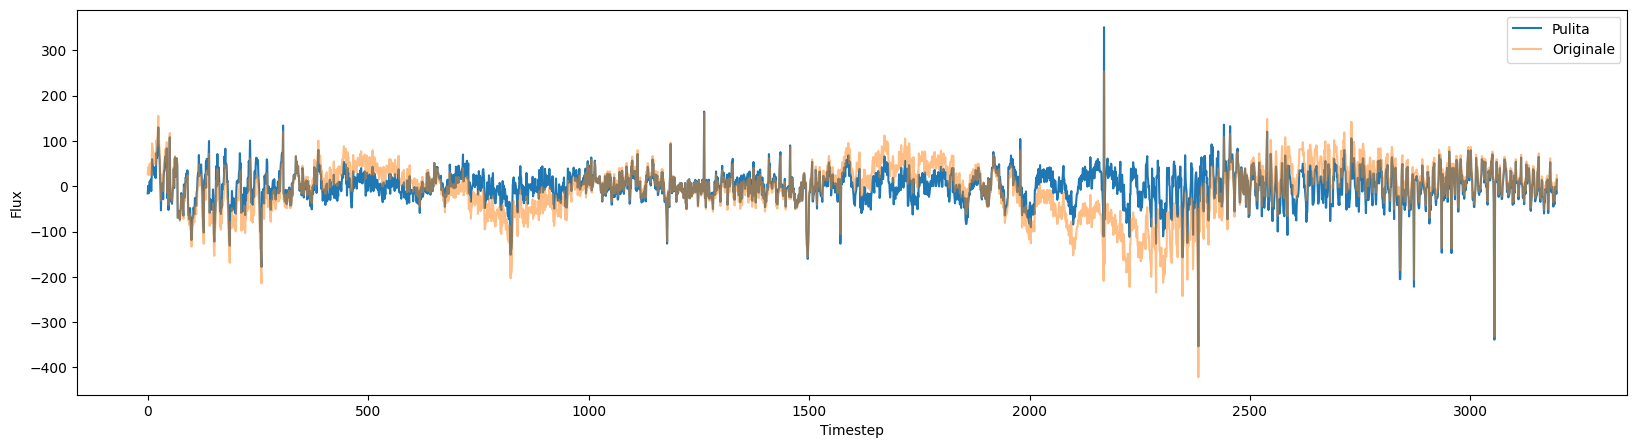

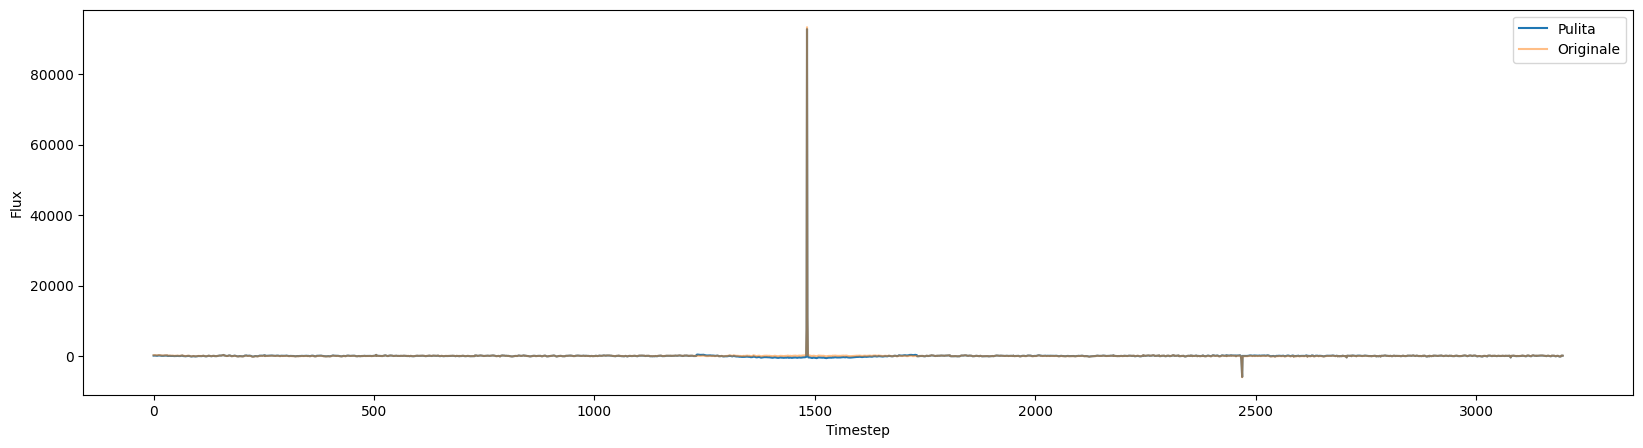

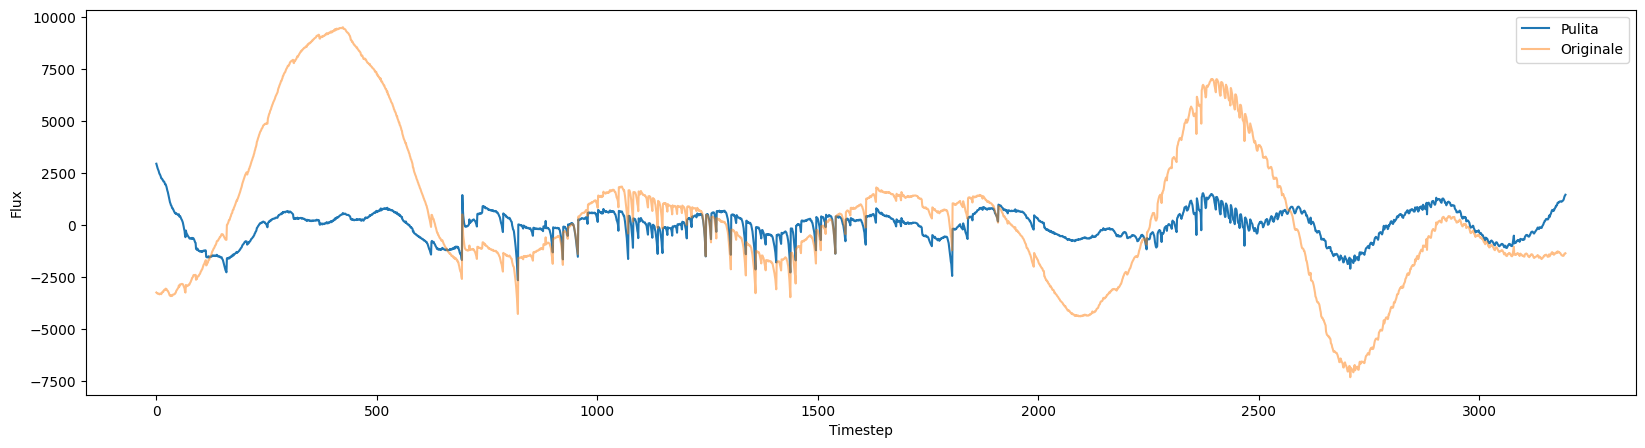

In [ ]:
X_train_raw1=X_train_raw.copy()
X_test_raw1=X_test_raw.copy()
for i in range(len(X_train_raw)):
  aux=sigma_clip(X_train_raw[i], sigma=3,maxiters=5)
  segnale_pulito=savgol_filter(aux, window_length=500, polyorder=2)
  X_train_raw1[i]=X_train_raw[i]-segnale_pulito
for i in range(len(X_test_raw)):
  aux=sigma_clip(X_test_raw[i], sigma=3, maxiters=5)
  segnale_pulito=savgol_filter(aux, window_length=500, polyorder=2)
  X_test_raw1[i]=X_test_raw[i]-segnale_pulito



for i in range(1,50,5):
  plt.figure(figsize=(20, 5))
  plt.plot(X_train_raw1[i], label="Pulita")
  plt.plot(X_train_raw[i],label="Originale", alpha=0.5)
  plt.ylabel("Flux")
  plt.xlabel("Timestep")
  plt.legend()
  plt.show()


Nel machine learning, la regola generale prevede che il processo di scaling venga calcolato sul train set e poi applicato al test set per evitare il data leakage (la contaminazione dei dati). Nei dataset classici (quelli tabulari), questo serve perché i dati condividono delle caratteristiche (feature) che seguono una distribuzione globale; standardizzare l'intero dataset serve quindi a mettere tutte le variabili sulla stessa scala, dato che ognuna di esse aggiunge informazioni utili sulla distribuzione generale.Nel caso corrente, però, la situazione è completamente diversa. Ogni curva di luce di Kepler è un sistema fisico a sé stante e non condivide alcuna informazione con le altre traiettorie. Sia il segnale del transito che il rumore di fondo dipendono esclusivamente dalla stella specifica che stiamo osservando e sono del tutto indipendenti dalle altre.Di conseguenza, per portare i dati su una scala numerica ideale che protegga la rete neurale dai problemi di gradient vanishing o exploding, ha perfettamente senso scalare ogni singola traiettoria considerando solo se stessa. Poiché la normalizzazione di una curva di luce inizia e finisce all'interno della traiettoria stessa, senza alcuna condivisione di parametri o statistiche con il resto del dataset, non c'è alcun rischio di data leakage. Per questo motivo, il processo può essere applicato in modo indipendente su tutte le traiettorie, sia del train che del test set.

In [ ]:
X_train_scaled = (X_train_raw1-np.mean(X_train_raw1,axis=1).reshape(-1,1))/np.std(X_train_raw1,axis=1).reshape(-1,1)
X_test_scaled  = (X_test_raw1-np.mean(X_test_raw1,axis=1).reshape(-1,1))/np.std(X_test_raw1,axis=1).reshape(-1,1)

print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled  shape: {X_test_scaled.shape}")


X_train_scaled shape: (5087, 3197)
X_test_scaled  shape: (570, 3197)


#Bilanciamento ed Estensione del Dataset (Data Augmentation)
Come evidenziato dall'analisi esplorativa, sia il dataset di addestramento (training set) sia quello di verifica (test set) presentano un forte sbilanciamento delle classi (unbalanced dataset). In ambito di Machine Learning, addestrare un modello su dati fortemente asimmetrici inficia la capacità di generalizzazione sulla classe minoritaria. Si rende quindi necessario un intervento di bilanciamento sul solo training set; al contrario, il test set non deve subire modifiche, al fine di garantire una valutazione realistica delle metriche di performance su dati non manipolati.
In linea con la letteratura e con i contenuti del corso, sono stati presi in considerazione tre approcci standard:
* Random Oversampling (Sovracampionamento): Consiste nel replicare casualmente le traiettorie della classe minoritaria (classe 2) fino al raggiungimento del pareggio numerico. Questa strategia è stata scartata in quanto non introduce nuova varianza informativa, aumentando linearmente il rischio di overfitting e saturando il modello con pattern ridondanti.
* Under-sampling basato su Ensemble (Sottocampionamento): Anziché ridurre drasticamente la classe maggioritaria (classe 1) perdendo informazioni preziose, si propone un approccio Ensemble (ispirato all'algoritmo EasyEnsemble). Il dataset della classe 1 viene suddiviso in \(N\) sotto-dataset disgiunti, ciascuno di dimensioni pari alla classe 2. Vengono quindi addestrati in parallelo \(N\) modelli differenti. Le predizioni finali verranno aggregate in fase di inferenza tramite tecniche di Hard Voting (maggioranza) o calcolando la media ponderata delle probabilità (Soft Voting).

* Generazione di dati sintetici (SMOTE / Interpolazione): Questa tecnica prevede la generazione di nuovi campioni interpolando geometricamente le feature dei vettori appartenenti alla classe minoritaria. Nel caso specifico di flussi stellari, l'applicazione naive di questo approccio è complessa: i flussi dipendono strettamente dalle caratteristiche intrinseche della stella (es. raggio, temperatura, magnitudine). Senza feature ancillari fisiche, l'interpolazione nello spazio delle feature potrebbe generare profili di transito fisicamente inconsistenti.

#Strategie di Data Augmentation Ad Hoc (Domain-Specific)
Sfruttando la natura fisico-geometrica delle serie temporali in esame, si propongono quattro tecniche di Data Augmentation mutuati dall'ambito delle reti neurali convoluzionali (CNN), ma adattate a segnali 1D:
* Jittering e Slicing (Rumore e Ritaglio): Introduzione di rumore bianco gaussiano a bassa ampiezza per simulare variazioni del rumore di fondo dello strumento, mantenendo inalterato il rapporto segnale-rumore (SNR) del transito. Parallelamente, si prevede il ritaglio (slicing) delle traiettorie, ponendo come vincolo fisico una lunghezza minima pari a 4 periodi orbitali, soglia ritenuta computazionalmente sufficiente per l'estrazione delle feature periodiche.
* Time Reversal (Inversione Temporale): Inversione dell'ordine cronologico della serie storica (\(t_{new} = T - t\)). Essendo il transito planetario un fenomeno geometricamente simmetrico rispetto al punto di minimo flusso (al netto di effetti di asimmetria atmosferica trascurabili), l'inversione conserva intatta la fisica del problema cinematica, raddoppiando efficacemente il campione.
* Local Permutation (Scambio Locale \t \leftrightarrow t+\Delta t): Scambio di misure tra istanti temporali adiacenti per un delta temporale infinitesimo. Questa operazione agisce come un perturbatore ad alta frequenza, simulando micro-errori di campionamento dello strumento senza distruggere la macro-struttura della curva di luce.
* Linear Combination (Combinazione Lineare di Traiettorie): Generazione di nuove curve effettuando somma algebrica di serie distinte (es: traj esopianeta+ traj non esopianeta, traj esopianeta+ traj esopianeta). Dal punto di vista astrofisico, tale operazione è coerente con il principio di sovrapposizione degli effetti luminosi e simula tre scenari reali:
  1. Assenza di transito simultaneo: I flussi di fondo si sommano linearmente, simulando una stella a magnitudine maggiore.
  2. Transito simultaneo (Sovrapposizione): Equivale geometricamente al transito di un pianeta di raggio maggiore (o combinato) davanti a una sorgente più luminosa.
  3. Transiti asincroni: Simula un sistema multi-planetario stocastico, scenario che la rete neurale deve comunque essere in grado di mapparli

In [ ]:
y_train_clean=y_train_raw.copy()
y_test_clean=y_test_raw.copy()

idx_pos = np.where(y_train_clean == 1)[0]
idx_neg = np.where(y_train_clean == 0)[0]
X_pos = X_train_scaled[idx_pos]
X_neg = X_train_scaled[idx_neg]

def augment_positive_samples(X_neg,X_pos, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(X_pos)
    n1=len(X_neg)
    augmented = [X_pos.copy()]

    #Time Reversal
    augmented.append(X_pos[:, ::-1].copy())

    # Gaussian Jitter
    noise_std = 0.05
    jitter = X_pos + rng.normal(0, noise_std, X_pos.shape)
    jitter=(jitter-np.mean(jitter,axis=1).reshape(-1,1))/np.std(jitter,axis=1).reshape(-1,1)
    augmented.append(jitter)

    # Linear Combination
    idx_pairs = rng.integers(0, n, size=n)
    alpha = rng.uniform(0.3, 0.7, size=(n, 1))
    lin_comb = alpha * X_pos + (1 - alpha) * X_pos[idx_pairs]
    lin_comb=(lin_comb-np.mean(lin_comb,axis=1).reshape(-1,1))/np.std(lin_comb,axis=1).reshape(-1,1)
    augmented.append(lin_comb)
    idx_pairs = rng.integers(0, n1, size=n)
    alpha = rng.uniform(0.7, 0.8, size=(n, 1))
    lin_comb = alpha * X_pos + (1 - alpha) * X_neg[idx_pairs]
    lin_comb=(lin_comb-np.mean(lin_comb,axis=1).reshape(-1,1))/np.std(lin_comb,axis=1).reshape(-1,1)
    augmented.append(lin_comb)


    X_aug = np.concatenate(augmented, axis=0)
    return X_aug

X_pos_aug = augment_positive_samples(X_neg,X_pos, random_state=42)
y_pos_aug = np.ones(len(X_pos_aug), dtype=np.int32)

print(f"\nAugmentation classe positiva: {len(X_pos)} → {len(X_pos_aug)} campioni")


Augmentation classe positiva: 37 → 185 campioni


Percorso salvataggio modelli trainati da utilizzare successivamente

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
MODEL_PATH = "/content/drive/MyDrive/kepler_models"
os.makedirs(MODEL_PATH, exist_ok=True)

Mounted at /content/drive


Una volta completata la fase di pre-elaborazione e normalizzazione del dataset, si può procedere con la progettazione e la configurazione delle architetture di reti neurali da addestrare.Per l'analisi di serie temporali e flussi fotometrici sequenziali, la letteratura e i contenuti del corso evidenziano due approcci principali, ciascuno basato su presupposti matematici e logici differenti:
* Reti Ricorrenti (LSTM - Long Short-Term Memory): Queste architetture sono specificamente progettate per elaborare dati sequenziali. Grazie a meccanismi interni di regolazione del flusso informativo (chiamati gate), le LSTM sono in grado di mantenere memoria delle informazioni osservate negli istanti temporali precedenti. Questa memoria a lungo termine permette al modello di correlare dinamicamente i dati correnti con l'andamento storico della curva di luce, facilitando l'identificazione di pattern complessi o variazioni su base temporale.
* Reti Convoluzionali (CNN 1D - Convolutional Neural Networks): Tradizionalmente impiegate nell'elaborazione di immagini, le reti convoluzionali si rivelano estremamente efficaci anche su serie storiche monodimensionali. La loro caratteristica principale è la capacità di analizzare i dati non singolarmente, ma attraverso finestre temporali locali (i filtri convoluzionali), la cui dimensione viene definita in fase di progettazione. Nel contesto delle curve di luce di Kepler, questo approccio è particolarmente vantaggioso: il transito di un pianeta si manifesta come un calo improvviso e localizzato della luminosità, seguito da un rapido ritorno alla baseline. I filtri della CNN consentono di catturare sia la forma geometrica di questo "dip" locale sia la sua periodicità complessiva lungo l'intera traiettoria, discriminando efficacemente il transito planetario dal rumore di fondo casuale.

In [ ]:
def build_cnn(input_shape):
    """CNN 1D per estrazione di pattern locali (forma del transito)."""
    model = Sequential(name="CNN_1D")
    model.add(Input(shape=input_shape))
    model.add(Conv1D(16, 5, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(32, 5, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(64, 3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=BinaryCrossentropy(),
        metrics=['accuracy',
                 FBetaScore(beta=1.0, threshold=0.5, average='micro', name='f1_score'),
                 KerasAUC(curve='ROC', name='roc_auc')]
    )
    return model

def build_cnn_lstm(input_shape):
    """CNN + BiLSTM: CNN estrae feature locali, LSTM cattura periodicità."""
    model = Sequential(name="CNN_BiLSTM")
    model.add(Input(shape=input_shape))
    # Blocco CNN
    model.add(Conv1D(16, 16, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=4))
    model.add(Conv1D(32, 8, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=4))
    # Blocco BiLSTM
    model.add(Bidirectional(LSTM(64, return_sequences=True)))
    model.add(Bidirectional(LSTM(32, return_sequences=False)))
    # Classificatore
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=BinaryCrossentropy(),
        metrics=['accuracy',
                 FBetaScore(beta=1.0, threshold=0.5, average='micro', name='f1_score'),
                 KerasAUC(curve='ROC', name='roc_auc')]
    )
    return model

def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=10, verbose=0,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                          min_lr=1e-6, verbose=0)
    ]

Per ovviare al forte sbilanciamento del dataset, che non può essere colmato interamente dalla sola Data Augmentation, si adotta una strategia basata su un Ensemble di Modelli addestrati su sotto-insiemi bilanciati.

Il flusso di lavoro si articola nelle seguenti fasi:
1) Generazione di \(N\) Dataset Bilanciati: Si creano \(N\) dataset indipendenti. Ognuno di essi contiene la totalità delle traiettorie con esopianeti (sia reali che generate tramite Data Augmentation) e un numero equivalente di traiettorie senza esopianeti, selezionate in modo casuale e dinamico dalla classe maggioritaria ad ogni iterazione. Questo approccio permette alla rete di esplorare nel tempo l'intera variabilità del rumore di fondo, ottimizzando l'aggiornamento dei pesi sinaptici senza polarizzarsi su un ristretto sottoinsieme di stelle negative.
2) Addestramento Concorrente di due Architetture (Conv1D e Conv1D-LSTM): Per ciascuno degli \(N\) dataset, vengono inizializzati e addestrati in parallelo due modelli distinti: una rete puramente convoluzionale monodimensionale (Conv1D) e un'architettura ibrida convoluzionale-ricorrente (Conv1D-LSTM). Al termine di ogni sessione di addestramento sul singolo dataset \(i\)-esimo, i pesi ottimali di entrambi i modelli vengono salvati e archiviati.
3) Aggregazione delle Predizioni (Ensemble Voting): Una volta completato l'addestramento degli N modelli, si costituisce un'architettura di voto centralizzata. In fase di inferenza (sul Test Set), ciascun modello esprime la propria predizione probabilistica indipendente. Tali output vengono infine combinati attraverso tecniche di aggregazione statistica (come il Majority Voting, la media aritmetica semplice o una media pesata basata sulle performance del singolo modello) per estrarre la classificazione finale, massimizzando la robustezza e riducendo la varianza dell'errore.

In [ ]:
def train_ensemble(
    X_pos_aug, y_pos_aug,
    X_neg, y_neg_full,
    n_models=10,
    n_folds=4,
    model_path=MODEL_PATH,
    session_id=1
):
    """
    Allena n_models coppie (CNN, CNN+LSTM) su sotto-dataset bilanciati.
    Ogni modello usa un subset diverso della classe maggioritaria.

    Returns
    -------
    results : dict con loss e AUC medi per ogni modello
    """
    n_pos = len(X_pos_aug)

    # Sotto-dataset disgiunti per la classe negativa (EasyEnsemble)
    subsets = [
        np.random.choice(len(X_neg), size=n_pos, replace=False)
        for _ in range(n_models)
    ]

    results = {
        'cnn':  {'loss_train': [], 'loss_val': [], 'auc_train': [], 'auc_val': []},
        'lstm': {'loss_train': [], 'loss_val': [], 'auc_train': [], 'auc_val': []}
    }

    for i in range(n_models):
        print(f"\n{'='*60}")
        print(f"  Modello {i+1}/{n_models}  (session {session_id})")
        print(f"{'='*60}")

        # Costruisce il sotto-dataset bilanciato
        X_neg_sub = X_neg[subsets[i]]
        y_neg_sub = y_neg_full[:n_pos]   # tutti 0

        X_bal = np.concatenate([X_pos_aug, X_neg_sub], axis=0)
        y_bal = np.concatenate([y_pos_aug, y_neg_sub], axis=0)

        # Shuffle
        shuf = np.random.permutation(len(X_bal))
        X_bal, y_bal = X_bal[shuf], y_bal[shuf]

        fold_metrics_cnn  = {'lt': [], 'lv': [], 'at': [], 'av': []}
        fold_metrics_lstm = {'lt': [], 'lv': [], 'at': [], 'av': []}

        kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

        for fold_idx, (idx_tr, idx_vl) in enumerate(kf.split(X_bal, y_bal)):
            print(f"  Fold {fold_idx+1}/{n_folds} — train: {len(idx_tr)}, val: {len(idx_vl)}")

            X_fold_tr, X_fold_vl = X_bal[idx_tr], X_bal[idx_vl]
            y_fold_tr, y_fold_vl = y_bal[idx_tr], y_bal[idx_vl]

            # Reshape y to (samples, 1) for FBetaScore
            y_fold_tr_reshaped = y_fold_tr.reshape(-1, 1)
            y_fold_vl_reshaped = y_fold_vl.reshape(-1, 1)


            # Reshape X for layer 1D: (samples, timesteps, 1)
            Xtr3 = X_fold_tr[:, :, np.newaxis]
            Xvl3 = X_fold_vl[:, :, np.newaxis]

            input_shape = (X_fold_tr.shape[1], 1)

            # ---- CORREZIONE: modello re-inizializzato ad ogni fold ----
            cnn_model  = build_cnn(input_shape)
            lstm_model = build_cnn_lstm(input_shape)

            # Class weights per gestire eventuali squilibri residui
            cw = compute_class_weight('balanced',
                                      classes=np.unique(y_fold_tr),
                                      y=y_fold_tr)
            class_weight_dict = {0: cw[0], 1: cw[1]}

            hist_cnn = cnn_model.fit(
                Xtr3, y_fold_tr_reshaped,
                validation_data=(Xvl3, y_fold_vl_reshaped),
                epochs=60, batch_size=16,
                class_weight=class_weight_dict,
                callbacks=get_callbacks(), verbose=0
            )
            hist_lstm = lstm_model.fit(
                Xtr3, y_fold_tr_reshaped,
                validation_data=(Xvl3, y_fold_vl_reshaped),
                epochs=60, batch_size=16,
                class_weight=class_weight_dict,
                callbacks=get_callbacks(), verbose=0
            )

            # Salva metriche della sestultima epoch valida. Meglio di salvare quelli dell'ultima epoca
            # per via dell'early stopping con attesa di 10 epoche di val loss peggiore rispetto al valore minimo
            fold_metrics_cnn['lt'].append(hist_cnn.history['loss'][-6])
            fold_metrics_cnn['lv'].append(hist_cnn.history['val_loss'][-6])
            fold_metrics_cnn['at'].append(hist_cnn.history['roc_auc'][-6])
            fold_metrics_cnn['av'].append(hist_cnn.history['val_roc_auc'][-6])

            fold_metrics_lstm['lt'].append(hist_lstm.history['loss'][-6])
            fold_metrics_lstm['lv'].append(hist_lstm.history['val_loss'][-6])
            fold_metrics_lstm['at'].append(hist_lstm.history['roc_auc'][-6])
            fold_metrics_lstm['av'].append(hist_lstm.history['val_roc_auc'][-6])

        # --- Ri-allena il modello FINALE su TUTTI i fold combinati ---
        # (usa i pesi medi appresi durante la CV come punto di partenza)
        X_bal_final = X_bal
        y_bal_final_reshaped = y_bal.reshape(-1, 1)
        X_bal_final3 = X_bal_final[:, :, np.newaxis]

        cnn_final  = build_cnn(input_shape)
        lstm_final = build_cnn_lstm(input_shape)

        cw_final = compute_class_weight('balanced',
                                        classes=np.unique(y_bal), y=y_bal)
        cw_dict_final = {0: cw_final[0], 1: cw_final[1]}

        cnn_final.fit(X_bal_final3, y_bal_final_reshaped,
                      validation_split=0.3,
                      epochs=60, batch_size=16,
                      class_weight=cw_dict_final,
                      callbacks=get_callbacks(), verbose=0)
        lstm_final.fit(X_bal_final3, y_bal_final_reshaped,
                       validation_split=0.3,
                       epochs=60, batch_size=16,
                       class_weight=cw_dict_final,
                       callbacks=get_callbacks(), verbose=0)

        # Salva i modelli finali
        cnn_final.save(os.path.join(model_path, f"cnn_{session_id}_{i}.keras"))
        lstm_final.save(os.path.join(model_path, f"lstm_{session_id}_{i}.keras"))

        # Registra metriche medie sui fold
        results['cnn']['loss_train'].append(np.mean(fold_metrics_cnn['lt']))
        results['cnn']['loss_val'].append(np.mean(fold_metrics_cnn['lv']))
        results['cnn']['auc_train'].append(np.mean(fold_metrics_cnn['at']))
        results['cnn']['auc_val'].append(np.mean(fold_metrics_cnn['av']))

        results['lstm']['loss_train'].append(np.mean(fold_metrics_lstm['lt']))
        results['lstm']['loss_val'].append(np.mean(fold_metrics_lstm['lv']))
        results['lstm']['auc_train'].append(np.mean(fold_metrics_lstm['at']))
        results['lstm']['auc_val'].append(np.mean(fold_metrics_lstm['av']))

        print(f"  CNN  — loss_val: {results['cnn']['loss_val'][-1]:.4f} | "
              f"AUC_val: {results['cnn']['auc_val'][-1]:.4f}")
        print(f"  LSTM — loss_val: {results['lstm']['loss_val'][-1]:.4f} | "
              f"AUC_val: {results['lstm']['auc_val'][-1]:.4f}")

    return results

Stampiamo ora i risultati finali

In [ ]:
def plot_training_results(results, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    axes[0].plot(results['cnn']['loss_train'],  'b-o', label='CNN train')
    axes[0].plot(results['cnn']['loss_val'],    'b--s', label='CNN val')
    axes[0].plot(results['lstm']['loss_train'], 'r-o', label='LSTM train')
    axes[0].plot(results['lstm']['loss_val'],   'r--s', label='LSTM val')
    axes[0].set_title(f"Loss per modello {title_suffix}")
    axes[0].set_xlabel("Modello #"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(results['cnn']['auc_train'],  'b-o', label='CNN train')
    axes[1].plot(results['cnn']['auc_val'],    'b--s', label='CNN val')
    axes[1].plot(results['lstm']['auc_train'], 'r-o', label='LSTM train')
    axes[1].plot(results['lstm']['auc_val'],   'r--s', label='LSTM val')
    axes[1].set_title(f"AUC-ROC per modello {title_suffix}")
    axes[1].set_xlabel("Modello #"); axes[1].set_ylabel("AUC")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()

Una volta salvati fatto ensamble sui singoli modelli CNN e CNN_LSTM possiamo procedere con il fare la media dei due

In [ ]:
def load_ensemble_and_predict(X_test_in, n_models, session_ids, model_path=MODEL_PATH):

    X3 = X_test_in[:, :, np.newaxis]

    preds_cnn  = []
    preds_lstm = []

    for s in session_ids:
        for i in range(n_models):
            path_cnn  = os.path.join(model_path, f"cnn_{s}_{i}.keras")
            path_lstm = os.path.join(model_path, f"lstm_{s}_{i}.keras")

            if os.path.exists(path_cnn):
                m = load_model(path_cnn)
                preds_cnn.append(m.predict(X3, verbose=0).flatten())
                del m

            if os.path.exists(path_lstm):
                m = load_model(path_lstm)
                preds_lstm.append(m.predict(X3, verbose=0).flatten())
                del m

    pred_cnn  = np.mean(preds_cnn,  axis=0) if preds_cnn  else None
    pred_lstm = np.mean(preds_lstm, axis=0) if preds_lstm else None

    if pred_cnn is not None and pred_lstm is not None:
        pred_avg = (pred_cnn + pred_lstm) / 2.0
    elif pred_cnn is not None:
        pred_avg = pred_cnn
    else:
        pred_avg = pred_lstm

    return pred_cnn, pred_lstm, pred_avg

Per poter confrontare i diversi modelli, le loro performance, gli errori, quali siano i casi in cui vengono commessi più valutazioni errate etc., procediamo con il calcolo di ROC ed AUC, PR-AUC, soglia ottimale di Youden, Confusion Matrix, Report di Classificazione e stime di incertezza via Bootstrap

In [ ]:
def youden_threshold(fpr, tpr, thresholds):
    """Soglia ottimale via indice di Youden: J = TPR - FPR."""
    J = tpr - fpr
    idx = np.argmax(J)
    return thresholds[idx], J[idx]


def evaluate_model_complete(y_true, y_prob, model_name="Modello"):
    """
    Valutazione completa di un classificatore binario:
      - AUC-ROC con intervallo di confidenza (bootstrap)
      - PR-AUC (più informativa con dataset sbilanciato)
      - Soglia ottimale di Youden
      - Confusion Matrix
      - Report di classificazione
      - Stime di incertezza via bootstrap

    Returns
    -------
    metrics : dict con tutte le metriche
    """
    print(f"\n{'='*60}")
    print(f"  VALUTAZIONE: {model_name}")
    print(f"{'='*60}")

    # ROC Curve
    fpr, tpr, thresholds_roc = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Soglia ottimale (Youden)
    opt_thresh, youden_j = youden_threshold(fpr, tpr, thresholds_roc)
    y_pred_opt = (y_prob >= opt_thresh).astype(int)
    y_pred_050 = (y_prob >= 0.50).astype(int)

    # PR Curve
    precision, recall, thresholds_pr = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    # Bootstrap per intervalli di confidenza su AUC-ROC
    n_bootstrap = 1000
    rng = np.random.default_rng(0)
    boot_auc = []
    boot_f1  = []
    for _ in range(n_bootstrap):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        fpr_b, tpr_b, _ = roc_curve(y_true[idx], y_prob[idx])
        boot_auc.append(auc(fpr_b, tpr_b))
        boot_f1.append(f1_score(y_true[idx], (y_prob[idx] >= opt_thresh).astype(int),
                                zero_division=0))

    auc_ci_low  = np.percentile(boot_auc, 2.5)
    auc_ci_high = np.percentile(boot_auc, 97.5)
    f1_mean     = np.mean(boot_f1)
    f1_ci_low   = np.percentile(boot_f1, 2.5)
    f1_ci_high  = np.percentile(boot_f1, 97.5)


    print(f"\n  AUC-ROC  : {roc_auc:.4f}  "
          f"(95% CI bootstrap: [{auc_ci_low:.4f}, {auc_ci_high:.4f}])")
    print(f"  PR-AUC   : {pr_auc:.4f}  "
          f"(baseline random: {y_true.mean():.4f})")
    print(f"\n  Soglia ottimale (Youden): {opt_thresh:.4f}  "
          f"(J = {youden_j:.4f})")
    print(f"  F1 @ soglia ottimale: {f1_mean:.4f}  "
          f"(95% CI: [{f1_ci_low:.4f}, {f1_ci_high:.4f}])")

    print(f"\n  --- Report @ soglia 0.50 ---")
    print(classification_report(y_true, y_pred_050,
                                 target_names=['No pianeta', 'Esopianeta'],
                                 zero_division=0))

    print(f"  --- Report @ soglia ottimale ({opt_thresh:.3f}) ---")
    print(classification_report(y_true, y_pred_opt,
                                 target_names=['No pianeta', 'Esopianeta'],
                                 zero_division=0))

    # Grafici
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f"Valutazione — {model_name}", fontsize=14)

    # ROC
    axes[0].plot(fpr, tpr, 'b-', lw=2,
                 label=f'AUC = {roc_auc:.4f}\n95%CI [{auc_ci_low:.4f}, {auc_ci_high:.4f}]')
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    axes[0].scatter([fpr[np.argmax(tpr - fpr)]],
                    [tpr[np.argmax(tpr - fpr)]],
                    color='red', zorder=5, s=80,
                    label=f'Youden @ {opt_thresh:.3f}')
    axes[0].fill_between(fpr, tpr, alpha=0.1)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve')
    axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

    # PR Curve
    axes[1].plot(recall, precision, 'g-', lw=2,
                 label=f'PR-AUC = {pr_auc:.4f}')
    axes[1].axhline(y=y_true.mean(), color='k', linestyle='--', lw=1,
                    label=f'Baseline = {y_true.mean():.4f}')
    axes[1].fill_between(recall, precision, alpha=0.1, color='green')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    # Confusion Matrix @ soglia ottimale
    cm = confusion_matrix(y_true, y_pred_opt)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No pianeta', 'Esopianeta'])
    disp.plot(ax=axes[2], colorbar=False)
    axes[2].set_title(f'Confusion Matrix\n(soglia = {opt_thresh:.3f})')

    plt.tight_layout(); plt.show()

    # Distribuzione delle probabilità predette
    fig2, ax = plt.subplots(figsize=(10, 4))
    ax.hist(y_prob[y_true == 0], bins=30, alpha=0.6, color='steelblue',
            label='No pianeta (label=0)', density=True)
    ax.hist(y_prob[y_true == 1], bins=10, alpha=0.6, color='tomato',
            label='Esopianeta (label=1)', density=True)
    ax.axvline(opt_thresh, color='black', linestyle='--', lw=2,
               label=f'Soglia Youden = {opt_thresh:.3f}')
    ax.axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Soglia 0.50')
    ax.set_xlabel('Probabilità predetta P(esopianeta)')
    ax.set_ylabel('Densità')
    ax.set_title(f'Distribuzione probabilità — {model_name}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    return {
        'roc_auc': roc_auc,
        'roc_auc_ci': (auc_ci_low, auc_ci_high),
        'pr_auc': pr_auc,
        'f1_mean': f1_mean,
        'f1_ci': (f1_ci_low, f1_ci_high),
        'opt_threshold': opt_thresh,
        'youden_j': youden_j,
        'confusion_matrix': cm,
        'fpr': fpr, 'tpr': tpr,
        'precision': precision, 'recall': recall
    }


La strategia descritta in precedenza si basa sul principio del Bagging (Bootstrap Aggregating), in cui molteplici modelli indipendenti (weak learners) vengono addestrati in parallelo su diverse porzioni di dati, combinando poi le loro risposte in un unico livello orizzontale.

Per ottimizzare ulteriormente l'unione dei diversi modelli, è possibile evolvere la strategia di Voting (la media semplice) verso un approccio di Stacking. In questo caso, il processo avviene in due fasi sequenziali. Nella prima fase, i modelli base (Conv1D e LSTM) vengono addestrati e congelati. Nella seconda fase, le predizioni generate da questi modelli vengono utilizzate come input per addestrare un ulteriore modello finale, chiamato Meta-Learner. Il compito del Meta-Learner è proprio quello di "imparare a combinare" i giudizi dei modelli precedenti: addestrandosi su questi output, l'algoritmo capisce sperimentalmente quali reti sono più affidabili in determinate situazioni e assegna loro il peso corretto, migliorando l'accuratezza della predizione finale.

In [ ]:
def build_stacking_meta_features(
    X_input, y_input,
    n_models, session_ids,
    model_path=MODEL_PATH,
    n_folds=5
):

    all_models = []
    for s in session_ids:
        for i in range(n_models):
            p_cnn  = os.path.join(model_path, f"cnn_{s}_{i}.keras")
            p_lstm = os.path.join(model_path, f"lstm_{s}_{i}.keras")
            if os.path.exists(p_cnn):
                all_models.append(('cnn', p_cnn))
            if os.path.exists(p_lstm):
                all_models.append(('lstm', p_lstm))

    n_base = len(all_models)
    meta_X = np.zeros((len(X_input), n_base))

    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    X3 = X_input[:, :, np.newaxis]

    for m_idx, (mtype, mpath) in enumerate(all_models):
        print(f"  OOF predictions — modello {m_idx+1}/{n_base}")
        oof_preds = np.zeros(len(X_input))

        for idx_tr, idx_vl in kf.split(X3, y_input):
            base_model = load_model(mpath)

            preds = base_model.predict(X3[idx_vl], verbose=0).flatten()
            oof_preds[idx_vl] = preds
            del base_model

        meta_X[:, m_idx] = oof_preds

    return meta_X


def train_and_evaluate_stacking(
    X_train_in, y_train_in,
    X_test_in, y_test_in,
    n_models, session_ids,
    model_path=MODEL_PATH
):
    """
    Allena il meta-learner su out-of-fold predictions e valuta sul test set.
    """
    print("\n--- Generazione out-of-fold meta-features (train) ---")
    meta_X_train = build_stacking_meta_features(
        X_train_in, y_train_in, n_models, session_ids, model_path
    )

    print("\n--- Predizioni dirette sul test set (media ensemble) ---")
    X3_test = X_test_in[:, :, np.newaxis]
    all_models = []
    for s in session_ids:
        for i in range(n_models):
            p_cnn  = os.path.join(model_path, f"cnn_{s}_{i}.keras")
            p_lstm = os.path.join(model_path, f"lstm_{s}_{i}.keras")
            if os.path.exists(p_cnn):
                all_models.append(p_cnn)
            if os.path.exists(p_lstm):
                all_models.append(p_lstm)

    meta_X_test = np.zeros((len(X_test_in), len(all_models)))
    for m_idx, mpath in enumerate(all_models):
        m = load_model(mpath)
        meta_X_test[:, m_idx] = m.predict(X3_test, verbose=0).flatten()
        del m

    # Meta-learner: regressione logistica
    meta_learner = LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    )
    meta_learner.fit(meta_X_train, y_train_in)

    y_prob_stack = meta_learner.predict_proba(meta_X_test)[:, 1]

    metrics = evaluate_model_complete(y_test_in, y_prob_stack,
                                       model_name="Ensemble Stacking")
    return meta_learner, y_prob_stack, metrics

L'ultima strategia valutata in questa analisi prevede un cambio di paradigma rispetto all'utilizzo diretto delle serie temporali grezze. Anziché affidare l'intera estrazione dei pattern ai filtri delle reti neurali, si è scelto di condurre l'addestramento a partire da metriche matematiche e fisiche calcolate esplicitamente sulle curve di luce originali.Il processo di ingegneria delle caratteristiche (Feature Engineering) si articola su due domini principali:Dominio del Tempo: Vengono calcolate grandezze statistiche fondamentali quali la media, la deviazione standard, l'asimmetria (skewness) e la curtosi, utili a descrivere la stabilità della baseline stellare e l'entità del rumore di fondo.Dominio della Frequenza: Attraverso l'applicazione della Trasformata di Fourier (FFT), il segnale viene convertito nel dominio delle frequenze. Questo passaggio è cruciale in astrofisica, poiché permette di estrarre le componenti periodiche dominanti e i picchi di potenza spettrale, separando matematicamente la periodicità rigorosa dei transiti planetari dalle variazioni pseudo-periodiche o casuali dell'attività stellare.Il nuovo dataset tabulare così ottenuto viene utilizzato per addestrare tre stimatori di alto livello basati sull'algoritmo di Gradient Boosting: XGBoost, LightGBM e CatBoost. Per massimizzare la capacità predittiva di ciascun modello e sintonizzarli sulle specificità dei dati fotometrici, viene impiegato il framework Optuna, conducendo una ricerca bayesiana automatizzata per l'ottimizzazione degli iperparametri (come la profondità degli alberi, il tasso di apprendimento e la regolarizzazione).Infine, le predizioni generate da questi tre modelli vengono aggregate attraverso un'architettura di Stacking. Sfruttando le predizioni Out-of-Fold per evitare fenomeni di data leakage, un meta-learner finale imparerà a pesare dinamicamente i contributi di XGBoost, LightGBM e CatBoost, combinando la specificità di ciascun algoritmo in un unico e robusto modello predittivo.


Estrazione feature tabular da X_train...
Feature tabular: 24 colonne
               mean           std          min          max    amplitude  \
count  5.087000e+03  5.087000e+03  5087.000000  5087.000000  5087.000000   
mean   1.611852e-11  1.000000e+00    -5.973561    17.058367    23.031927   
std    6.867928e-09  4.891990e-08     5.178571    12.986645    12.349187   
min   -2.983029e-08  9.999998e-01   -43.606491     0.401634     2.990146   
25%   -4.176240e-09  9.999999e-01    -7.056973     6.986009    13.763870   
50%    0.000000e+00  1.000000e+00    -4.198069    12.902964    20.140511   
75%    4.176240e-09  1.000000e+00    -3.040869    23.987162    30.417557   
max    3.340992e-08  1.000000e+00    -0.298188    56.182083    59.203255   

          skewness     kurtosis      abs_sum          iqr           p1  ...  \
count  5087.000000  5087.000000  5087.000000  5087.000000  5087.000000  ...   
mean      5.446153   233.615585  1994.747437     0.943291    -2.112027  ...   
std     

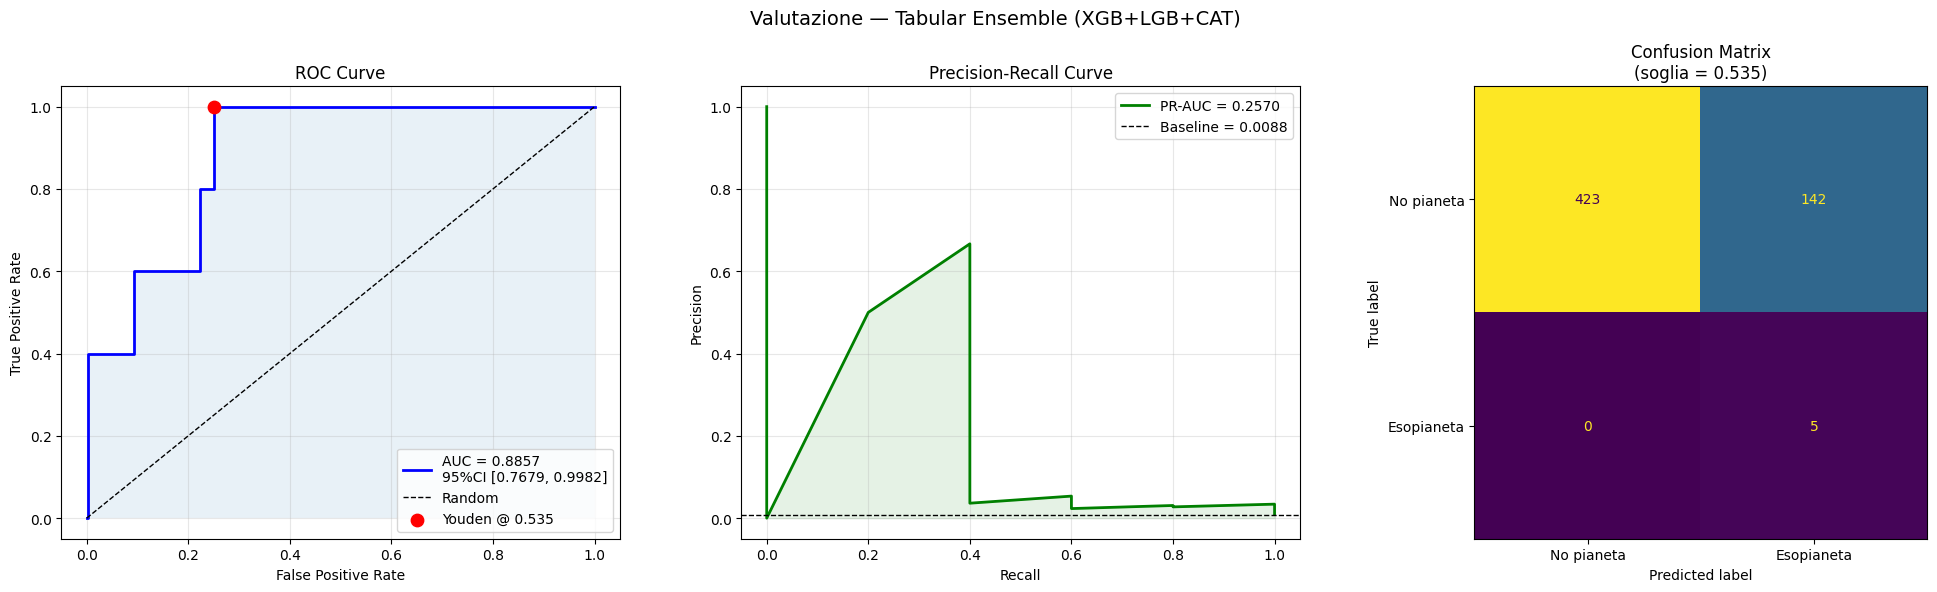

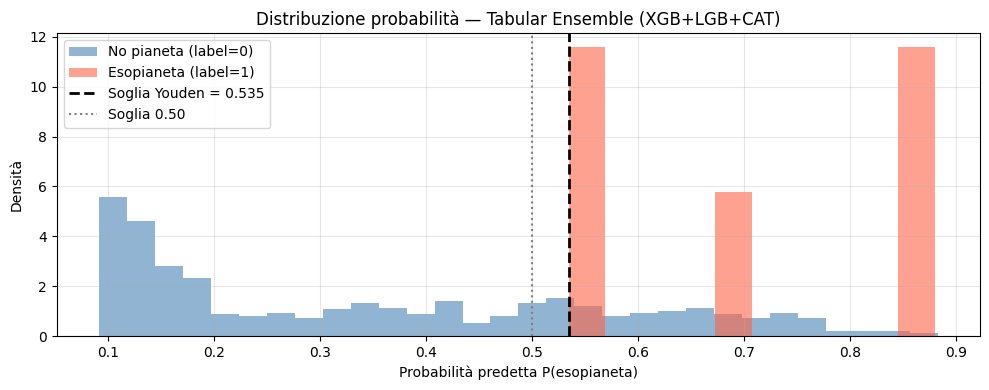

In [ ]:
def extract_tabular_features(X):
    """
    Estrae feature statistiche e spettrali da ogni curva di luce.
    Include trasformata di Fourier per catturare la periodicità.
    """
    features = {}

    features['mean']      = np.mean(X, axis=1)
    features['std']       = np.std(X, axis=1)
    features['min']       = np.min(X, axis=1)
    features['max']       = np.max(X, axis=1)
    features['amplitude'] = features['max'] - features['min']
    features['skewness']  = skew(X, axis=1)
    features['kurtosis']  = kurtosis(X, axis=1)
    features['abs_sum']   = np.sum(np.abs(X), axis=1)
    features['iqr']       = np.percentile(X, 75, axis=1) - np.percentile(X, 25, axis=1)

    # Percentili
    for p in [1, 5, 95, 99]:
        features[f'p{p}'] = np.percentile(X, p, axis=1)

    #  FFT: top-5 frequenze per potenza (periodicità)
    fft_power = np.abs(rfft(X, axis=1))**2
    # Scarta il termine DC (frequenza 0)
    fft_power_no_dc = fft_power[:, 1:]
    top5_idx = np.argsort(fft_power_no_dc, axis=1)[:, -5:]
    freqs = rfftfreq(X.shape[1])[1:]
    for k in range(5):
        features[f'fft_top{k+1}_freq']  = freqs[top5_idx[:, -(k+1)]]
        features[f'fft_top{k+1}_power'] = fft_power_no_dc[
            np.arange(len(X)), top5_idx[:, -(k+1)]
        ]

    # Rapporto potenza nel range di frequenze tipiche di esopianeti
    total_power = fft_power[:, 1:].sum(axis=1)
    features['fft_total_power'] = total_power

    return pd.DataFrame(features)


print("\nEstrazione feature tabular da X_train...")
df_train_tab = extract_tabular_features(X_train_scaled)
df_test_tab  = extract_tabular_features(X_test_scaled)

print(f"Feature tabular: {df_train_tab.shape[1]} colonne")
print(df_train_tab.describe())



try:
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    from catboost import CatBoostClassifier
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    TABULAR_AVAILABLE = True
except ImportError:
    print("XGBoost/LightGBM/CatBoost non disponibili. Installa con pip.")
    TABULAR_AVAILABLE = False

if TABULAR_AVAILABLE:
    def make_optuna_objective(model_name, X_tab, y_tab, kf):
        X_arr = np.array(X_tab)
        y_arr = np.array(y_tab)

        def objective(trial):
            if model_name == "xgb":
                params = {
                    'n_estimators':     trial.suggest_int('n_estimators', 300, 800),
                    'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
                    'max_depth':        trial.suggest_int('max_depth', 3, 8),
                    'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
                    'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
                    'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
                    'scale_pos_weight': (y_arr == 0).sum() / max((y_arr == 1).sum(), 1)
                }
                def make_m():
                    return XGBClassifier(**params, tree_method="hist",
                                         eval_metric='logloss',
                                         n_jobs=-1, random_state=42)

            elif model_name == "lgb":
                params = {
                    'n_estimators':      trial.suggest_int('n_estimators', 300, 800),
                    'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
                    'max_depth':         trial.suggest_int('max_depth', 3, 12),
                    'num_leaves':        trial.suggest_int('num_leaves', 20, 100),
                    'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
                    'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
                    'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
                    'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
                    'is_unbalance':      True,
                }
                def make_m():
                    return LGBMClassifier(**params, verbose=-1,
                                          random_state=42, n_jobs=-1)

            elif model_name == "cat":
                params = {
                    'iterations':          trial.suggest_int('iterations', 300, 800),
                    'learning_rate':       trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
                    'depth':               trial.suggest_int('depth', 3, 8),
                    'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
                    'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
                    'auto_class_weights': 'Balanced',
                }
                def make_m():
                    return CatBoostClassifier(**params, verbose=0,
                                               allow_writing_files=False,
                                               random_state=42)

            # Cross-validation interna per Optuna
            scores = []
            for idx_tr, idx_vl in kf.split(X_arr, y_arr):
                m = make_m()
                m.fit(X_arr[idx_tr], y_arr[idx_tr])
                proba = m.predict_proba(X_arr[idx_vl])[:, 1]
                scores.append(average_precision_score(y_arr[idx_vl], proba))
            return np.mean(scores)

        return objective

    # EasyEnsemble per modelli tabular
    idx_pos_tab = np.where(y_train_clean == 1)[0]
    idx_neg_tab = np.where(y_train_clean == 0)[0]
    n_pos_tab   = len(idx_pos_tab)
    n_models_tab = 5

    kf_tab = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    all_tab_preds = []
    best_params_xgb, best_params_lgb, best_params_cat = [], [], []

    for t_i in range(n_models_tab):
        print(f"\n--- Tabular Ensemble {t_i+1}/{n_models_tab} ---")

        sub_neg = np.random.choice(idx_neg_tab, size=n_pos_tab, replace=False)
        idx_sub = np.concatenate([idx_pos_tab, sub_neg])
        np.random.shuffle(idx_sub)

        X_sub = df_train_tab.iloc[idx_sub].values
        y_sub = y_train_clean[idx_sub]

        # Tuning XGBoost
        study_xgb = optuna.create_study(direction='maximize')
        study_xgb.optimize(make_optuna_objective("xgb", X_sub, y_sub, kf_tab),
                           n_trials=30, show_progress_bar=False)
        best_params_xgb.append(study_xgb.best_params)

        # Tuning LightGBM
        study_lgb = optuna.create_study(direction='maximize')
        study_lgb.optimize(make_optuna_objective("lgb", X_sub, y_sub, kf_tab),
                           n_trials=30, show_progress_bar=False)
        best_params_lgb.append(study_lgb.best_params)

        # Tuning CatBoost
        study_cat = optuna.create_study(direction='maximize')
        study_cat.optimize(make_optuna_objective("cat", X_sub, y_sub, kf_tab),
                           n_trials=20, show_progress_bar=False)
        best_params_cat.append(study_cat.best_params)

        # Allena modelli finali con best params su X_sub
        xgb_m = XGBClassifier(**best_params_xgb[-1], tree_method="hist",
                               scale_pos_weight=(y_sub==0).sum()/(y_sub==1).sum(),
                               eval_metric='logloss', n_jobs=-1, random_state=42)
        lgb_m = LGBMClassifier(**best_params_lgb[-1], is_unbalance=True,
                                verbose=-1, random_state=42, n_jobs=-1)
        cat_m = CatBoostClassifier(**best_params_cat[-1], auto_class_weights='Balanced',
                                    verbose=0, allow_writing_files=False, random_state=42)

        xgb_m.fit(X_sub, y_sub)
        lgb_m.fit(X_sub, y_sub)
        cat_m.fit(X_sub, y_sub)

        X_test_tab_arr = df_test_tab.values
        p_xgb = xgb_m.predict_proba(X_test_tab_arr)[:, 1]
        p_lgb = lgb_m.predict_proba(X_test_tab_arr)[:, 1]
        p_cat = cat_m.predict_proba(X_test_tab_arr)[:, 1]

        all_tab_preds.append((p_xgb + p_lgb + p_cat) / 3.0)

        print(f"  XGB best PR-AUC: {study_xgb.best_value:.4f}")
        print(f"  LGB best PR-AUC: {study_lgb.best_value:.4f}")
        print(f"  CAT best PR-AUC: {study_cat.best_value:.4f}")

    # Media delle predizioni tabular
    y_prob_tabular = np.mean(all_tab_preds, axis=0)
    metrics_tab = evaluate_model_complete(
        y_test_raw, y_prob_tabular, model_name="Tabular Ensemble (XGB+LGB+CAT)"
    )

In [ ]:
# Stampa la lista delle GPU rilevate
gpus = tf.config.list_physical_devices('GPU')
print("Numero di GPU disponibili: ", len(gpus))
if gpus:
    print("GPU rilevata:", gpus[0])
else:
    print("ATTENZIONE: Nessuna GPU rilevata. Il codice girerà sulla CPU!")

Numero di GPU disponibili:  1
GPU rilevata: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')




  SESSIONE 1: Training su dataset originale + augmentation

  Modello 1/10  (session 1)
  Fold 1/4 — train: 277, val: 93
  Fold 2/4 — train: 277, val: 93
  Fold 3/4 — train: 278, val: 92
  Fold 4/4 — train: 278, val: 92
  CNN  — loss_val: 0.1121 | AUC_val: 0.9912
  LSTM — loss_val: 0.1846 | AUC_val: 0.9846

  Modello 2/10  (session 1)
  Fold 1/4 — train: 277, val: 93
  Fold 2/4 — train: 277, val: 93
  Fold 3/4 — train: 278, val: 92
  Fold 4/4 — train: 278, val: 92
  CNN  — loss_val: 0.0695 | AUC_val: 0.9979
  LSTM — loss_val: 0.2036 | AUC_val: 0.9713

  Modello 3/10  (session 1)
  Fold 1/4 — train: 277, val: 93
  Fold 2/4 — train: 277, val: 93
  Fold 3/4 — train: 278, val: 92
  Fold 4/4 — train: 278, val: 92
  CNN  — loss_val: 0.0750 | AUC_val: 0.9958
  LSTM — loss_val: 0.1857 | AUC_val: 0.9842

  Modello 4/10  (session 1)
  Fold 1/4 — train: 277, val: 93
  Fold 2/4 — train: 277, val: 93
  Fold 3/4 — train: 278, val: 92
  Fold 4/4 — train: 278, val: 92
  CNN  — loss_val: 0.1138 | AUC

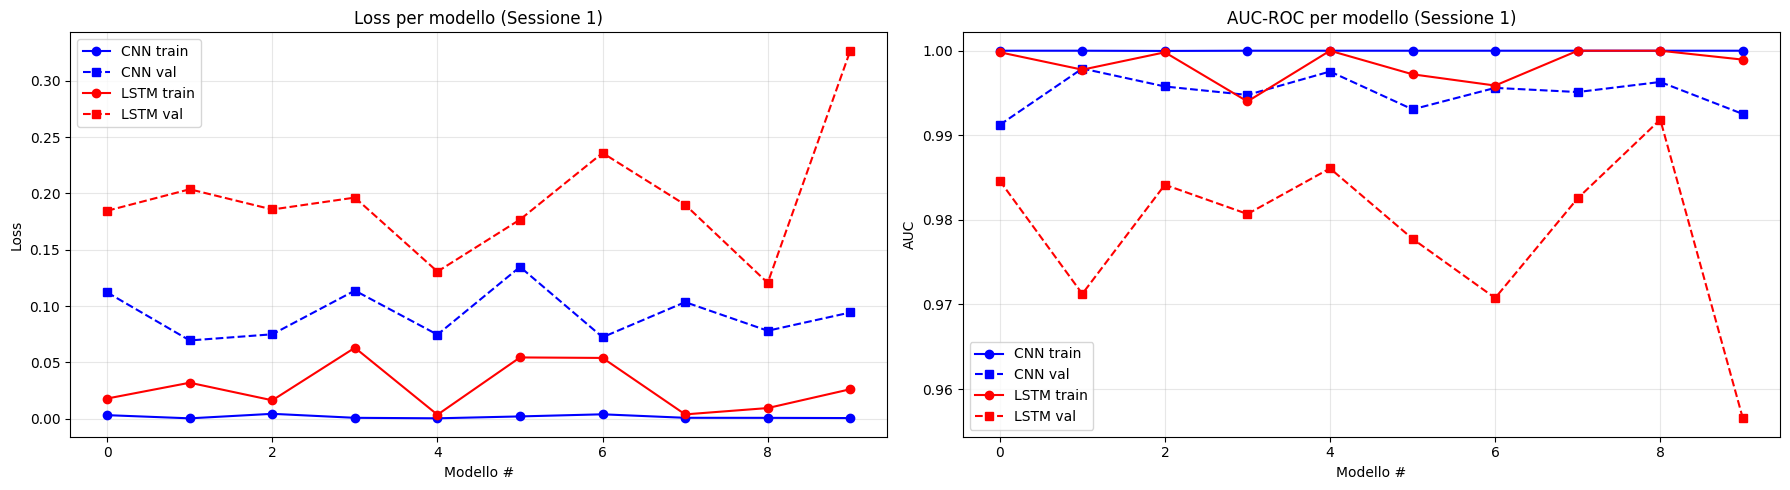



  INFERENZA ENSEMBLE SUL TEST SET

  VALUTAZIONE: CNN Ensemble

  AUC-ROC  : 0.9869  (95% CI bootstrap: [0.9564, 1.0000])
  PR-AUC   : 0.6421  (baseline random: 0.0088)

  Soglia ottimale (Youden): 0.2379  (J = 0.9451)
  F1 @ soglia ottimale: 0.2413  (95% CI: [0.0625, 0.4103])

  --- Report @ soglia 0.50 ---
              precision    recall  f1-score   support

  No pianeta       1.00      0.98      0.99       565
  Esopianeta       0.24      0.80      0.36         5

    accuracy                           0.98       570
   macro avg       0.62      0.89      0.68       570
weighted avg       0.99      0.98      0.98       570

  --- Report @ soglia ottimale (0.238) ---
              precision    recall  f1-score   support

  No pianeta       1.00      0.95      0.97       565
  Esopianeta       0.14      1.00      0.24         5

    accuracy                           0.95       570
   macro avg       0.57      0.97      0.61       570
weighted avg       0.99      0.95      0.97   

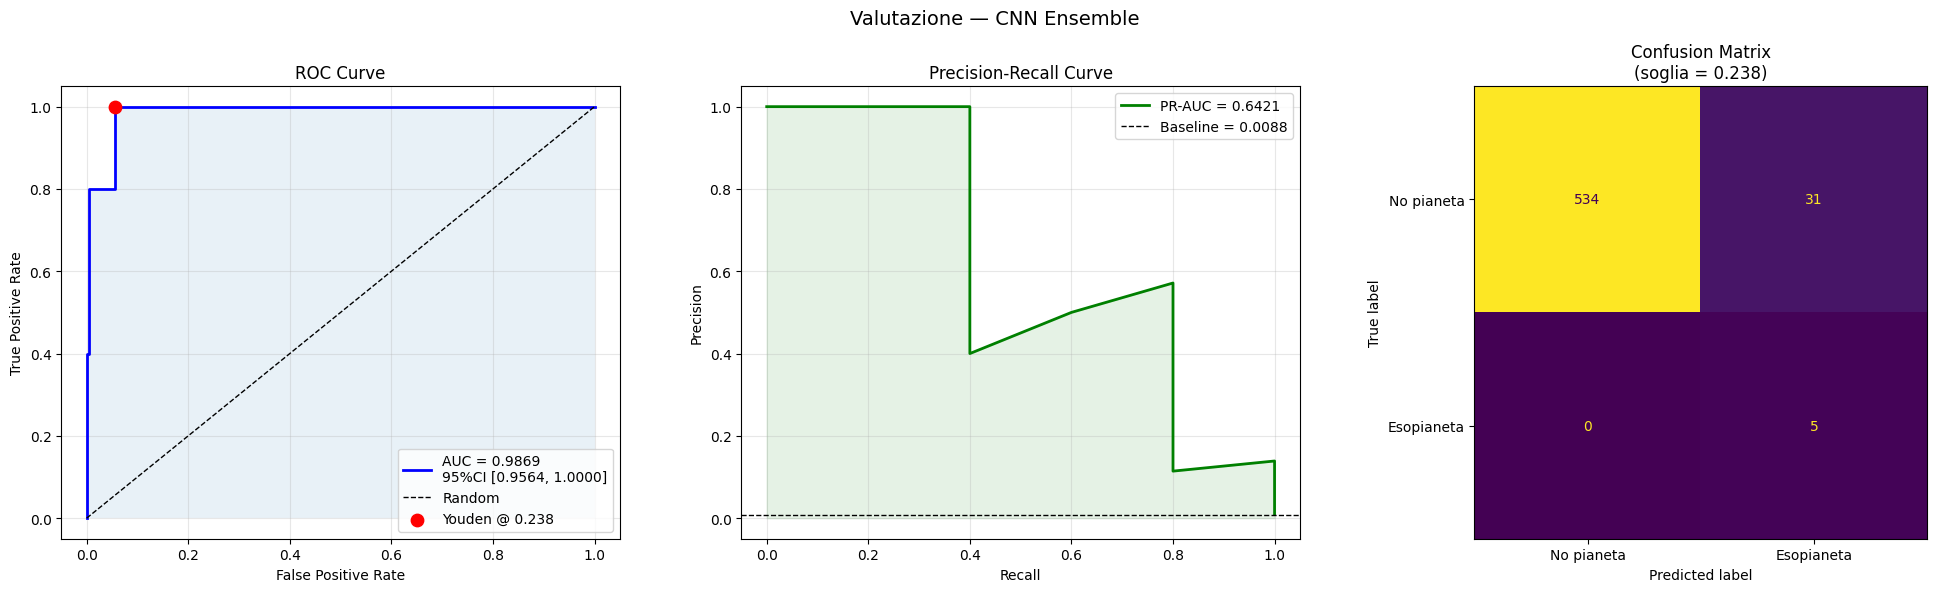

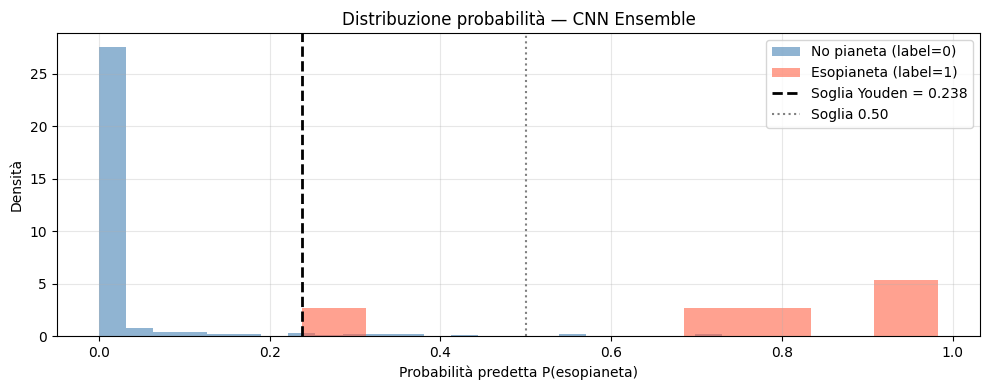


  VALUTAZIONE: CNN+LSTM Ensemble

  AUC-ROC  : 0.9926  (95% CI bootstrap: [0.9819, 1.0000])
  PR-AUC   : 0.5714  (baseline random: 0.0088)

  Soglia ottimale (Youden): 0.8272  (J = 0.9841)
  F1 @ soglia ottimale: 0.5168  (95% CI: [0.1983, 0.7692])

  --- Report @ soglia 0.50 ---
              precision    recall  f1-score   support

  No pianeta       1.00      0.96      0.98       565
  Esopianeta       0.17      1.00      0.29         5

    accuracy                           0.96       570
   macro avg       0.58      0.98      0.63       570
weighted avg       0.99      0.96      0.97       570

  --- Report @ soglia ottimale (0.827) ---
              precision    recall  f1-score   support

  No pianeta       1.00      0.98      0.99       565
  Esopianeta       0.36      1.00      0.53         5

    accuracy                           0.98       570
   macro avg       0.68      0.99      0.76       570
weighted avg       0.99      0.98      0.99       570



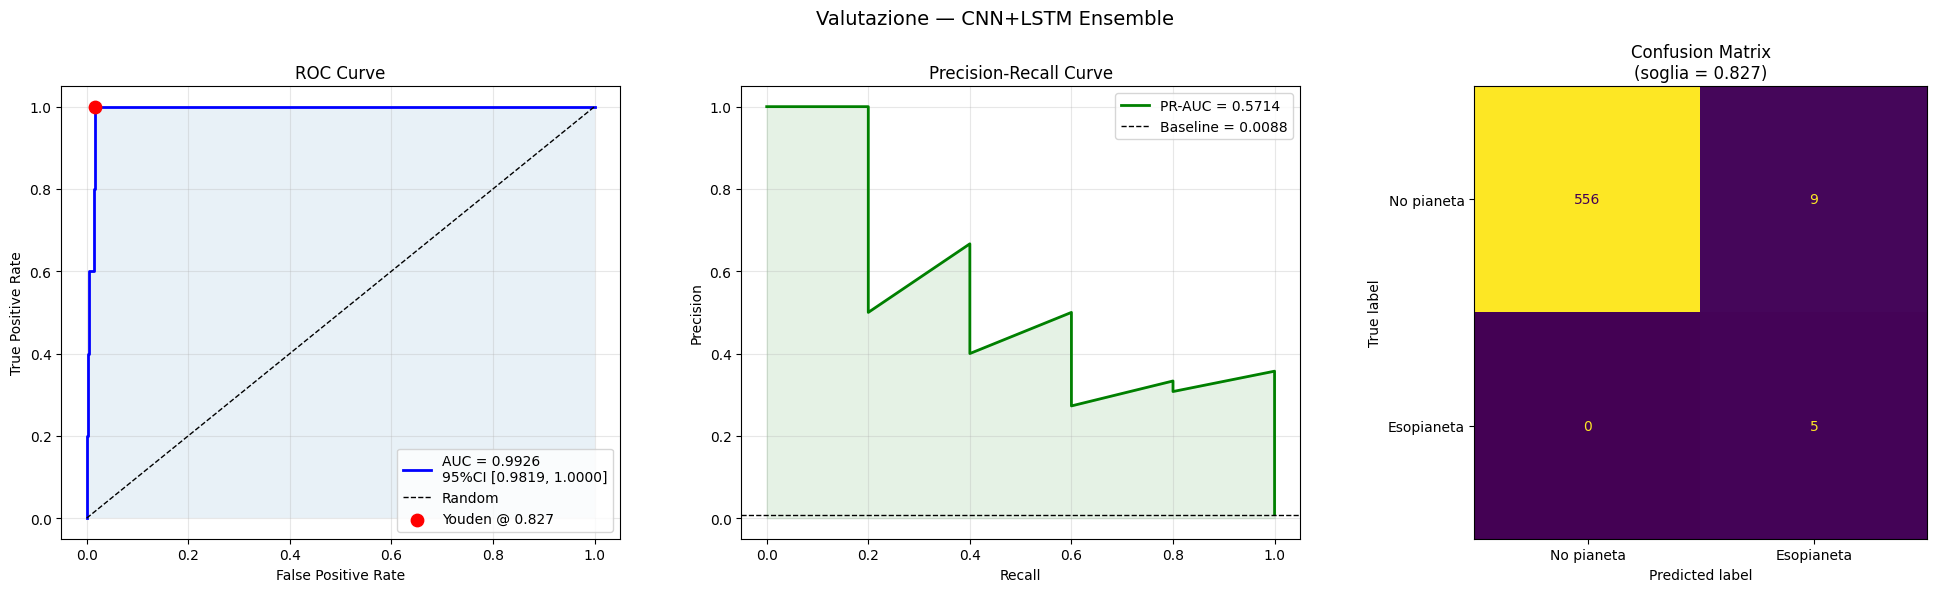

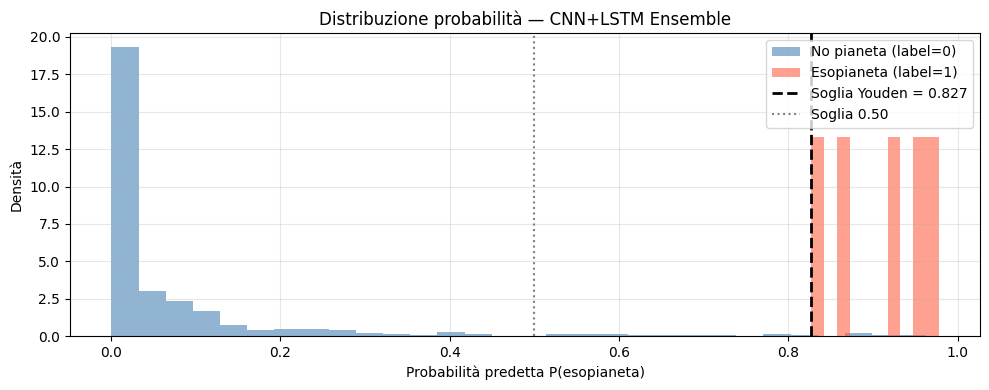


  VALUTAZIONE: CNN+LSTM Average Ensemble

  AUC-ROC  : 0.9979  (95% CI bootstrap: [0.9920, 1.0000])
  PR-AUC   : 0.8909  (baseline random: 0.0088)

  Soglia ottimale (Youden): 0.5326  (J = 0.9894)
  F1 @ soglia ottimale: 0.6157  (95% CI: [0.2824, 0.8759])

  --- Report @ soglia 0.50 ---
              precision    recall  f1-score   support

  No pianeta       1.00      0.99      0.99       565
  Esopianeta       0.42      1.00      0.59         5

    accuracy                           0.99       570
   macro avg       0.71      0.99      0.79       570
weighted avg       0.99      0.99      0.99       570

  --- Report @ soglia ottimale (0.533) ---
              precision    recall  f1-score   support

  No pianeta       1.00      0.99      0.99       565
  Esopianeta       0.45      1.00      0.62         5

    accuracy                           0.99       570
   macro avg       0.73      0.99      0.81       570
weighted avg       1.00      0.99      0.99       570



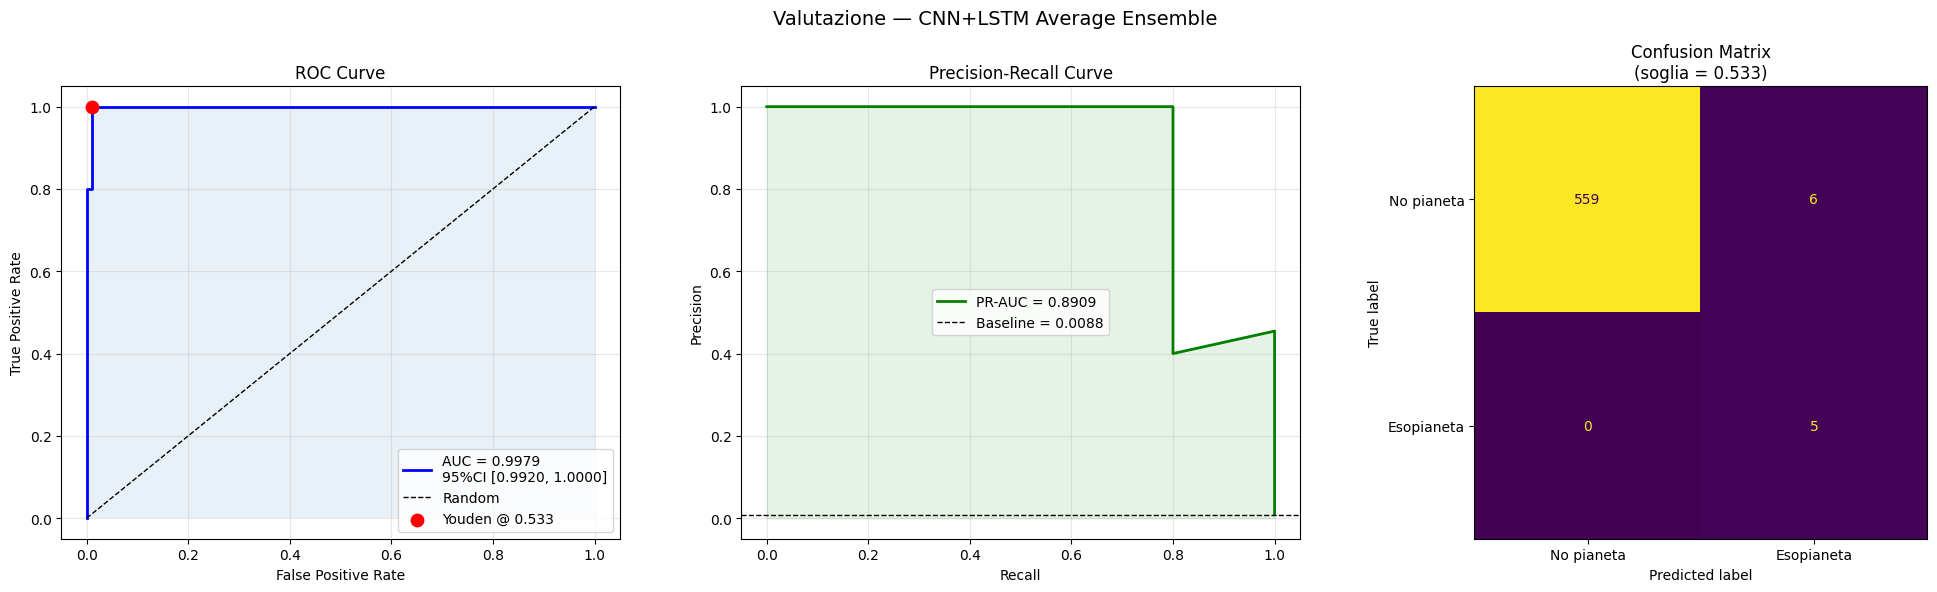

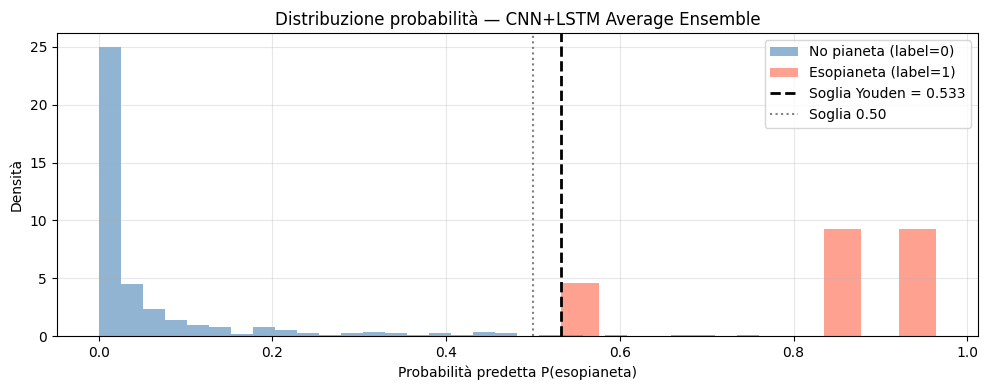

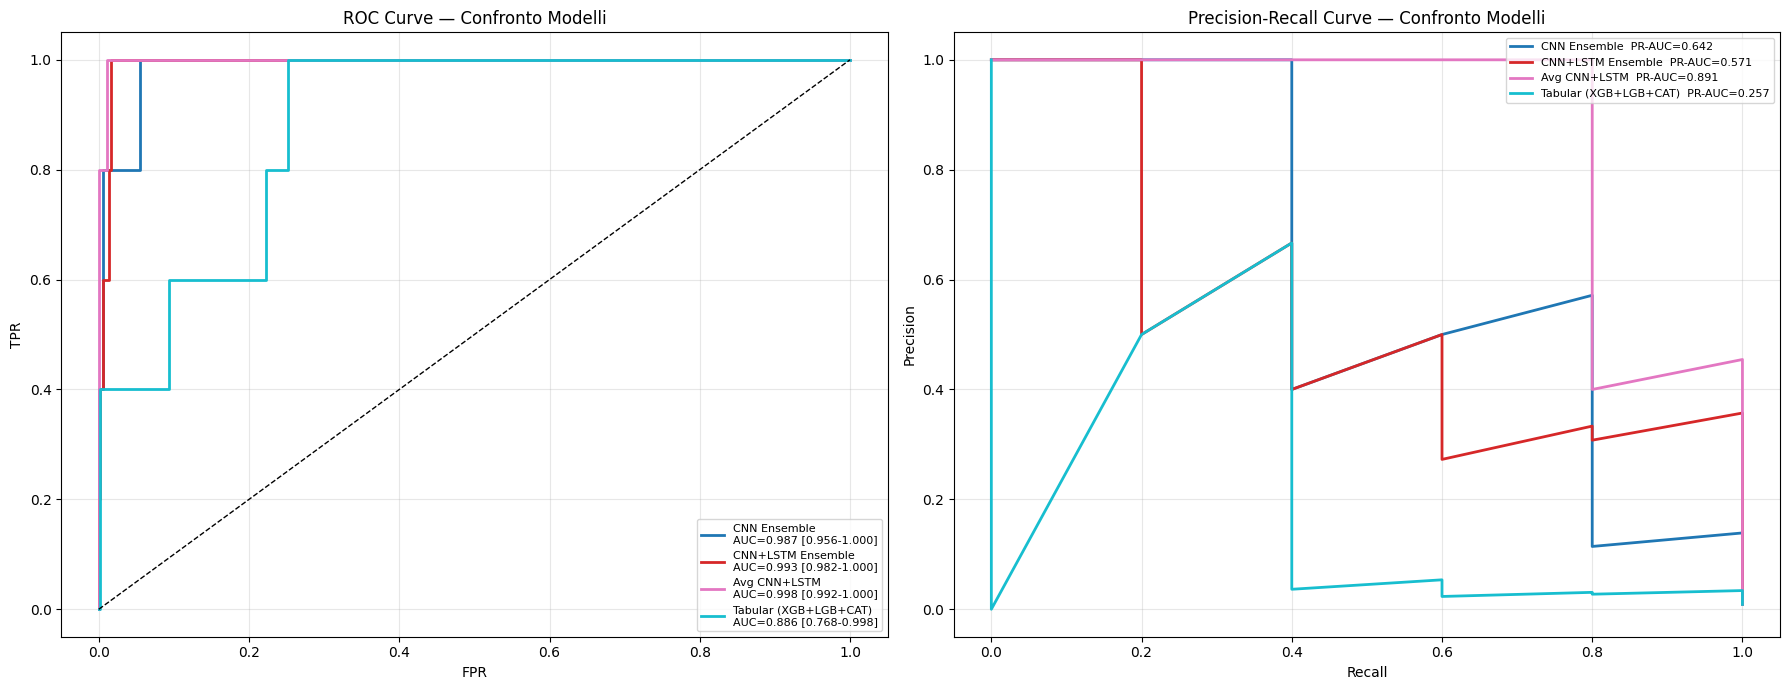

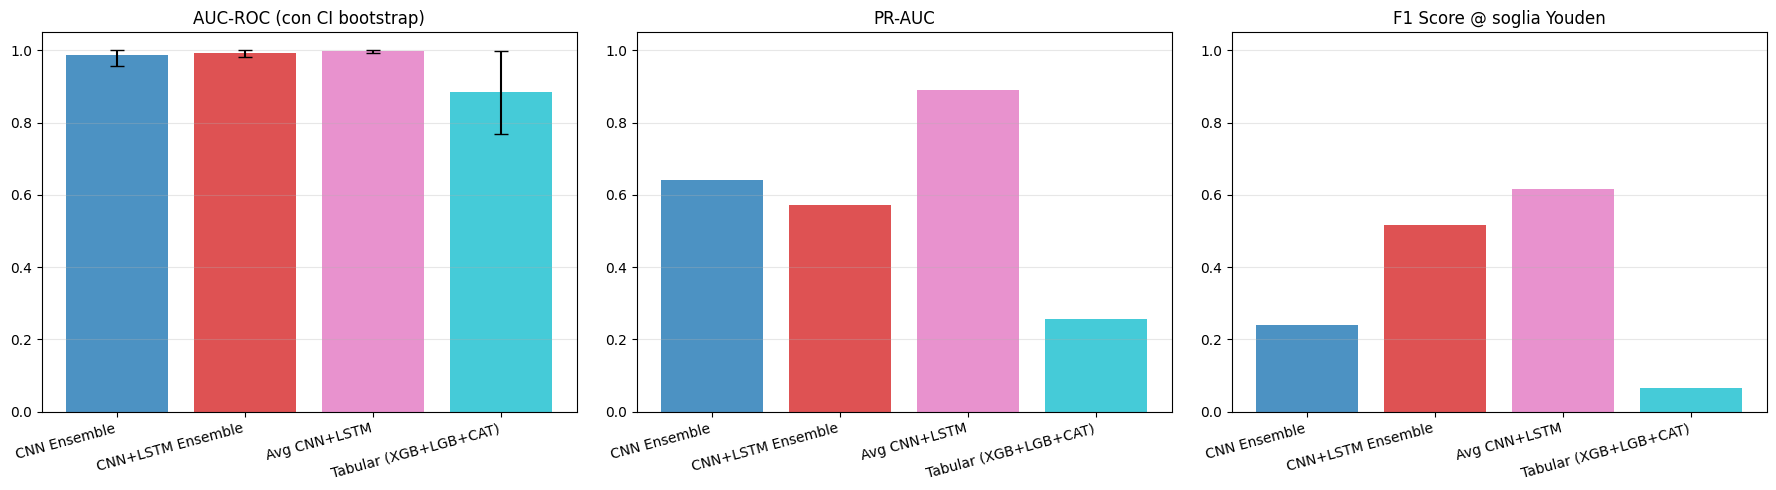


  RIEPILOGO FINALE — METRICHE SUL TEST SET
Modello                         AUC-ROC             95% CI   PR-AUC       F1   Soglia
----------------------------------------------------------------------
CNN Ensemble                     0.9869      [0.956,1.000]   0.6421   0.2413   0.2379
CNN+LSTM Ensemble                0.9926      [0.982,1.000]   0.5714   0.5168   0.8272
Avg CNN+LSTM                     0.9979      [0.992,1.000]   0.8909   0.6157   0.5326
Tabular (XGB+LGB+CAT)            0.8857      [0.768,0.998]   0.2570   0.0660   0.5346

Nota: PR-AUC è la metrica più informativa per dataset sbilanciati.
Baseline PR-AUC casuale = 0.0088 (5 positivi su 570 campioni)


In [ ]:

print("\n\n" + "="*60)
print("  SESSIONE 1: Training su dataset originale + augmentation")
print("="*60)

y_neg_zeros = np.zeros(len(X_neg), dtype=np.int32)

results_s1 = train_ensemble(
    X_pos_aug, y_pos_aug,
    X_neg,  y_neg_zeros,
    n_models=10,
    n_folds=4,
    model_path=MODEL_PATH,
    session_id=1
)
plot_training_results(results_s1, title_suffix="(Sessione 1)")


print("\n\n" + "="*60)
print("  INFERENZA ENSEMBLE SUL TEST SET")
print("="*60)

pred_cnn, pred_lstm, pred_avg = load_ensemble_and_predict(
    X_test_scaled,
    n_models=10,
    session_ids=[1],
    model_path=MODEL_PATH
)

# Valutazione separata per CNN, LSTM e media
metrics_cnn  = evaluate_model_complete(y_test_raw, pred_cnn,  "CNN Ensemble")
metrics_lstm = evaluate_model_complete(y_test_raw, pred_lstm, "CNN+LSTM Ensemble")
metrics_avg  = evaluate_model_complete(y_test_raw, pred_avg,  "CNN+LSTM Average Ensemble")


def plot_model_comparison(metrics_dict):
    """
    Sovrappone le ROC curve di tutti i modelli per confronto diretto.
    Aggiunge anche un grafico a barre per AUC-ROC e PR-AUC.
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    colors = plt.cm.tab10(np.linspace(0, 1, len(metrics_dict)))

    for (name, m), color in zip(metrics_dict.items(), colors):
        label_roc = (f"{name}\n"
                     f"AUC={m['roc_auc']:.3f} "
                     f"[{m['roc_auc_ci'][0]:.3f}-{m['roc_auc_ci'][1]:.3f}]")
        axes[0].plot(m['fpr'], m['tpr'], lw=2, color=color, label=label_roc)

        label_pr = f"{name}  PR-AUC={m['pr_auc']:.3f}"
        axes[1].plot(m['recall'], m['precision'], lw=2, color=color, label=label_pr)

    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title('ROC Curve — Confronto Modelli')
    axes[0].legend(loc='lower right', fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve — Confronto Modelli')
    axes[1].legend(loc='upper right', fontsize=8); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()

    # Barchart riassuntiva
    fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
    names   = list(metrics_dict.keys())
    aucs    = [m['roc_auc'] for m in metrics_dict.values()]
    pr_aucs = [m['pr_auc']  for m in metrics_dict.values()]
    f1s     = [m['f1_mean'] for m in metrics_dict.values()]
    ci_low  = [m['roc_auc'] - m['roc_auc_ci'][0] for m in metrics_dict.values()]
    ci_high = [m['roc_auc_ci'][1] - m['roc_auc'] for m in metrics_dict.values()]

    x = np.arange(len(names))
    axes2[0].bar(x, aucs, yerr=[ci_low, ci_high], capsize=5,
                 color=colors[:len(names)], alpha=0.8)
    axes2[0].set_xticks(x); axes2[0].set_xticklabels(names, rotation=15, ha='right')
    axes2[0].set_title('AUC-ROC (con CI bootstrap)'); axes2[0].set_ylim(0, 1.05)
    axes2[0].grid(axis='y', alpha=0.3)

    axes2[1].bar(x, pr_aucs, color=colors[:len(names)], alpha=0.8)
    axes2[1].set_xticks(x); axes2[1].set_xticklabels(names, rotation=15, ha='right')
    axes2[1].set_title('PR-AUC'); axes2[1].set_ylim(0, 1.05)
    axes2[1].grid(axis='y', alpha=0.3)

    axes2[2].bar(x, f1s, color=colors[:len(names)], alpha=0.8)
    axes2[2].set_xticks(x); axes2[2].set_xticklabels(names, rotation=15, ha='right')
    axes2[2].set_title('F1 Score @ soglia Youden')
    axes2[2].set_ylim(0, 1.05); axes2[2].grid(axis='y', alpha=0.3)

    plt.tight_layout(); plt.show()


# Costruisci dizionario metriche
all_metrics = {
    'CNN Ensemble':          metrics_cnn,
    'CNN+LSTM Ensemble':     metrics_lstm,
    'Avg CNN+LSTM':          metrics_avg,
}
if TABULAR_AVAILABLE:
    all_metrics['Tabular (XGB+LGB+CAT)'] = metrics_tab

plot_model_comparison(all_metrics)


# RIEPILOGO NUMERICO FINALE

print("\n" + "="*70)
print("  RIEPILOGO FINALE — METRICHE SUL TEST SET")
print("="*70)
print(f"{'Modello':<30} {'AUC-ROC':>8} {'95% CI':>18} {'PR-AUC':>8} {'F1':>8} {'Soglia':>8}")
print("-"*70)
for name, m in all_metrics.items():
    ci = f"[{m['roc_auc_ci'][0]:.3f},{m['roc_auc_ci'][1]:.3f}]"
    print(f"{name:<30} {m['roc_auc']:>8.4f} {ci:>18} "
          f"{m['pr_auc']:>8.4f} {m['f1_mean']:>8.4f} {m['opt_threshold']:>8.4f}")
print("="*70)
print("\nNota: PR-AUC è la metrica più informativa per dataset sbilanciati.")
print(f"Baseline PR-AUC casuale = {y_test_raw.mean():.4f} "
      f"({y_test_raw.sum()} positivi su {len(y_test_raw)} campioni)")

# Parte 2

In [ ]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter
from astropy.stats import sigma_clip
warnings.filterwarnings("ignore")

In [ ]:
def load_kepler_data(path):
    import pandas as pd
    train = pd.read_csv(os.path.join(path, "exoTrain.csv"))
    test  = pd.read_csv(os.path.join(path, "exoTest.csv"))
    X_train = train.drop(columns=["LABEL"]).values
    y_train = train["LABEL"].values
    X_test  = test.drop(columns=["LABEL"]).values
    y_test  = test["LABEL"].values
    print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
    return X_train, y_train, X_test, y_test

Analogamente a quanto eseguito nella prima sezione, prima di procedere con l'addestramento dei modelli applichiamo una pipeline di filtraggio per ottenere un dataset più affidabile e privo di informazioni ridondanti o spurie (come le oscillazioni dovute all'attività magnetica stellare, la comparsa di macchie solari o il rumore strumentale).In questa fase, oltre al filtro di Savitzky-Golay (Savgol filter), viene introdotto preliminarmente il Sigma-Clipping. Questo algoritmo è fondamentale per identificare ed eliminare i valori di luminosità anomali (outliers o spike isolati) che si discostano di oltre \(3\sigma\) dalla media locale.La rimozione preventiva di questi artefatti è una condizione necessaria per la corretta esecuzione del filtro Savgol. Dal momento che questo secondo filtro si basa su un'interpolazione polinomiale locale a minimi quadrati (che equivale matematicamente a massimizzare la Log-Likelihood sotto l'assunto di rumore gaussiano), la presenza di spike isotropi distorcerebbe pesantemente la funzione interpolante deputata a descrivere la baseline di fondo (background). Se non si applicasse il Sigma-Clipping, l'algoritmo di ottimizzazione cercherebbe di minimizzare l'errore sui residui modificando i coefficienti del polinomio per assecondare il valore anomalo; ciò causerebbe una forte distorsione locale, allontanando la curva stimata dal reale andamento del flusso stellare continuo.

Quello che si vuole dunque fare in questo modo è marginalizzare una fonte di segnale non utile per l'analisi che si vuole condurre

In [ ]:
def preprocess(X, sg_window=300, sg_poly=2, clip_sigma=3.0, clip_iters=8):
    """
    Per ogni curva:
      - sigma clipping  (rimuove spike da raggi cosmici)
      - Savitzky-Golay  (stima la baseline lenta)
      - sottrazione baseline + z-score
    """
    cleaned = np.zeros_like(X, dtype=float)
    for i, curve in enumerate(X):
        clipped  = sigma_clip(curve, sigma=clip_sigma, maxiters=clip_iters)
        baseline = savgol_filter(clipped, sg_window, sg_poly)
        residual = curve - baseline
        cleaned[i] = residual
    mu  = cleaned.mean(axis=1, keepdims=True)
    std = cleaned.std(axis=1, keepdims=True)
    std[std == 0] = 1
    return (cleaned - mu) / std

Una volta pre-elaborati i dati di interesse, si procede con l'implementazione di algoritmi dedicati all'estrazione delle grandezze geometriche fondamentali della curva di luce (Light Curve, LC): la profondità dei minimi, la durata del transito e le relative incertezze statistiche.

1. Identificazione dei Minimi tramite Ricerca Locale Stocastica:
Per localizzare i minimi idonei, viene implementato un algoritmo di ricerca locale iterativa (assimilabile a una variante semplificata di Random Walk o Hill Climbing). Definito un punto temporale di partenza $p_0$ con il rispettivo flusso registrato $f_0$ , l'algoritmo esplora lo spazio circostante entro un raggio d'azione r. Vengono cercati i punti temporali nell'intorno che mostrano un flusso inferiore a quello corrente (𝑓<𝑓0). Se viene individuato un punto p′  con una profondità maggiore (flusso minore), la posizione di riferimento viene aggiornata (𝑝0=𝑝′) e la procedura viene ripetuta iterativamente; in caso contrario, il punto corrente viene isolato e catalogato come minimo locale.
2. Determinazione della Durata del Transito tramite Dinamica Cinetica Euristica: Per identificare la durata dei transiti, viene sviluppato un metodo euristico e fenomenologico che combina i principi dell'ottimizzazione stocastica e del gradiente con momento. Il segnale viene preventivamente invertito , trasformando i cali di luce in picchi positivi.L'approccio simula il comportamento fisico di una "pallina" posizionata in un punto iniziale $p_0$, alla quale vengono assegnate una velocità iniziale $v_0$ e uno spostamento temporale discretizzato Δ𝑡, generato casualmente con direzione positiva o negativa. Se il dislivello di flusso complessivo tra la posizione iniziale e quella finale $p′$ supera l'energia cinetica legata alla velocità della pallina, il moto si arresta nella posizione corrente. In caso contrario, la posizione viene aggiornata (𝑝0=𝑝′) e la velocità viene ricalcolata incorporando il gradiente locale: 𝑣′=𝑣0−Δ𝑓(𝑝0,𝑝′). Il processo si ripete fino al raggiungimento della condizione di arresto. Questo approccio introduce un'incertezza sistematica intrinseca, strettamente legata alla scelta dell'ampiezza massima di Δ𝑡.In corrispondenza dei massimi del segnale invertito (ossia i minimi reali della curva di luce), i corpi simulati tendono ad arrestarsi, permettendo di identificare la fase di ingresso (ingress) e di emersione (egress) del transito. L'ipotesi fisica alla base del metodo assume che, lontano dai transiti, il gradiente sia nullo (Δ𝑓≈0), consentendo alle palline di muoversi liberamente fino a convergere in prossimità del picco, senza fermarsi nelle regioni stazionarie della baseline.
3. Raggruppamento tramite Binning e Calcolo dei Parametri: I punti di arresto così identificati vengono aggregati tramite istogrammi a intervalli (binning) per mappare la distribuzione dei conteggi attorno ai singoli transiti. Sfruttando intervalli temporali della corretta ampiezza, si osservano picchi di densità in corrispondenza dei transiti, che degradano fino a zero nelle zone stazionarie.Procedendo lungo l'asse temporale, l'approssimarsi di un transito è caratterizzato da una crescita monotona dei conteggi, seguita da una decrescita una volta superato il picco. Al ritorno a una densità di conteggio prossima allo zero, tutti i bin compresi tra l'inizio della salita e il termine della discesa vengono assegnati al medesimo evento di transito. Isolando i due versanti (il pendio destro e quello sinistro), viene calcolata la media geometrica dei punti di ciascun gruppo per determinare la posizione temporale media dell'ingresso e dell'emersione del pianeta. La differenza tra questi due valori definisce l'ampiezza (durata) del transito, mentre il delta numerico tra la baseline fotometrica e il flusso registrato al minimo determina la profondità finale del transito.

In [ ]:
def min_max_idfy(segnale_matrix, raggio, plot=False):
    """
    Parametri
    ---------
    segnale_matrix : ndarray (N_curve, T)
    raggio         : int — ampiezza della finestra di ricerca locale
    plot           : bool

    Restituisce
    -----------
    indici : list of list — per ogni curva, la lista delle posizioni
             di convergenza (una per ogni punto di partenza)
    """
    indici = []

    for l in range(segnale_matrix.shape[0]):
        segnale = segnale_matrix[l]
        n = len(segnale)
        pos = np.arange(n, dtype=int)

        for k in range(n):
            count = 0
            while count < 20:
                auxpiu  = pos[k] + np.arange(5, raggio)
                auxmeno = pos[k] - np.arange(5, raggio)
                piu  = auxpiu[(auxpiu  >= 0) & (auxpiu  < n)]
                meno = auxmeno[(auxmeno >= 0) & (auxmeno < n)]
                minipos = np.concatenate([piu, meno])
                if len(minipos) == 0:
                    break
                diff = segnale[minipos] - segnale[pos[k]]
                mini = np.argmin(diff)
                if diff[mini] < 0:
                    pos[k] = minipos[mini]
                    count = 0
                else:
                    count += 1

        indici.append(pos.tolist())

        if plot:
            fig, (ax_top, ax_bot) = plt.subplots(
                2, 1, figsize=(15, 5), sharex=True,
                gridspec_kw={"height_ratios": [3, 1]}
            )
            ax_top.plot(segnale, color="royalblue", lw=0.8, label="Flusso")
            ax_top.set_ylabel("Ampiezza Segnale")
            ax_top.grid(True, ls="--", alpha=0.5)
            ax_top.legend()
            ax_top.spines["bottom"].set_visible(False)

            num, bins = np.histogram(indici[l], bins=250)
            centri    = (bins[:-1] + bins[1:]) / 2
            width_bar = bins[1] - bins[0]
            ax_bot.bar(centri, num, width=width_bar, color="green", alpha=0.7)
            ax_bot.set_ylabel("Conteggi")
            ax_bot.set_xlabel("Tempo (campioni)")
            ax_bot.grid(True, ls="--", alpha=0.5)
            ax_bot.spines["top"].set_visible(False)
            fig.subplots_adjust(hspace=0.0)
            plt.show()

    return indici




def identif_max(segnale_matrix, prove, t_meno, t_piu):
    """
    Parametri
    ---------
    segnale_matrix : ndarray (N_curve, T)
    prove          : int — numero di tentativi per ogni punto j
    t_meno, t_piu  : int — range per il campionamento casuale di |del_t|

    Restituisce
    -----------
    pos_final : list of list — per ogni curva, le posizioni j
                registrate come bordi (inizio della salita bloccante)
    """
    pos_final = []
    vel_vals  = np.linspace(0, 1, 10)

    for l in range(segnale_matrix.shape[0]):
        pos_final.append([])
        segnale = segnale_matrix[l].reshape(1, -1)
        n       = segnale.shape[1]
        sigma   = np.std(segnale)
        vel_low = sigma * 3
        vel_hi  = sigma * 3 + 0.001

        vel   = np.random.uniform(vel_low, vel_hi, size=(prove, n))
        del_t = np.random.choice(range(t_meno, t_piu), size=(prove, n))
        del_t[del_t == 0]  =  4
        del_t[del_t >  0] +=  1
        del_t[del_t <  0] -= 1
        segni = np.sign(del_t)

        for i in range(prove):
            for j in range(n):
                t = int(j + del_t[i, j])

                if 0 <= t <= n - 1:
                    aux  = segnale[0, j:t:int(segni[i, j])]
                    aux1 = aux[1:] - aux[:-1]
                    somma = float(np.cumsum(aux1)[-1]) if aux1.size > 0 else 4.0

                    if somma > vel[i, j]:

                        pos_final[l].append(j)
                    else:

                        vel[i, j]   = np.random.uniform(vel_low, vel_hi)
                        del_t[i, j] = segni[i, j] * np.random.choice(range(1, abs(t_piu) + 1))
                else:

                    segni[i, j]  *= -1
                    del_t[i, j]   = segni[i, j] * np.random.choice(range(1, abs(t_piu) + 1))

    return pos_final

def inizio_fine(segnale, indici_min, indici_max, soglia=10, n_bins=450, opt=False):
    """
    Parametri
    ---------
    segnale     : ndarray (T,)
    indici_min  : ndarray — convergenze MCMC (output min_max_idfy, una curva)
    indici_max  : ndarray — bordi di transito (output identif_max, una curva)
    soglia      : int — conteggio minimo per considerare un bin come bordo attivo
    n_bins      : int — bins dell'istogramma dei bordi
    opt         : bool — mostra scatter dei bordi

    Restituisce
    -----------
    media_durata, err_durata, media_profondita, err_profondita
    """
    indici_min = np.asarray(indici_min)
    indici_max = np.asarray(indici_max)

    # Individua le finestre temporali dei transiti dall'istogramma dei bordi
    counts, bins = np.histogram(indici_max, bins=n_bins)
    finestre = []
    val_min = []
    dentro   = False
    t_start  = None

    for i in range(1, len(counts)):
        if counts[i] > soglia and not dentro:
            t_start = bins[i]
            dentro  = True
        if counts[i] <= soglia and dentro:
            finestre.append((t_start, bins[i]))
            dentro = False
    if dentro:
        finestre.append((t_start, bins[-1]))

    if opt and len(finestre) > 0:
        bordi_flat = np.array(finestre).flatten()
        plt.scatter(bordi_flat, np.zeros(len(bordi_flat)), s=5)
        plt.title("Bordi dei transiti individuati")
        plt.show()

    if len(finestre) == 0:
        return np.nan, np.nan, np.nan, np.nan

    amp       = []   # durate
    dev_amp   = []   # errori durate
    media_dep = []   # profondità
    sigma_dep = []   # errori profondità

    for t_ini, t_fin in finestre:
        # Centro del transito = media dei minimi in questa finestra
        minimi_loc = indici_min[(indici_min >= t_ini) & (indici_min <= t_fin)]
        if len(minimi_loc) == 0:
            continue
        centro = float(np.mean(minimi_loc))
        se_centro=np.std(minimi_loc)/np.sqrt(len(minimi_loc))

        bordi_sx = indici_max[(indici_max >= t_ini) & (indici_max <  centro)]
        bordi_dx = indici_max[(indici_max >  centro) & (indici_max <= t_fin)]
        if len(bordi_sx) == 0 or len(bordi_dx) == 0:
            continue

        bordi_sx = bordi_sx.astype(int)
        bordi_dx = bordi_dx.astype(int)

        #  Durata
        mu_sx   = np.mean(bordi_sx);  se_sx = np.std(bordi_sx) / np.sqrt(len(bordi_sx))
        mu_dx   = np.mean(bordi_dx);  se_dx = np.std(bordi_dx) / np.sqrt(len(bordi_dx))
        durata  = mu_dx - mu_sx
        err_dur = np.sqrt(se_sx**2 + se_dx**2)

        #  Profondità: flusso medio sui bordi laterali
        val_sx     = segnale[bordi_sx]
        val_dx     = segnale[bordi_dx]
        prof       = np.abs( (np.mean(val_sx) + np.mean(val_dx)) / 2 - segnale[int(centro)] )
        se_val_sx  = np.std(val_sx) / np.sqrt(len(val_sx))
        se_val_dx  = np.std(val_dx) / np.sqrt(len(val_dx))
        err_prof   = np.sqrt((se_val_sx**2 + se_val_dx**2) / 4 + se_centro**2)

        amp.append(durata)
        dev_amp.append(err_dur)
        media_dep.append(prof)
        sigma_dep.append(err_prof)

    if len(amp) == 0:
        return np.nan, np.nan, np.nan, np.nan

    amp       = np.array(amp)
    dev_amp   = np.array(dev_amp)
    media_dep = np.array(media_dep)
    sigma_dep = np.array(sigma_dep)

    # Media pesata su tutti i transiti trovati nella curva (peso = 1/σ²)
    w_dur = 1.0 / np.where(dev_amp   > 0, dev_amp**2,   1e-3)
    w_pro = 1.0 / np.where(sigma_dep > 0, sigma_dep**2, 1e-3)

    media_durata     = np.sum(w_dur * amp)       / np.sum(w_dur)
    err_durata       = 1.0 / np.sqrt(np.sum(w_dur))
    media_profondita = np.sum(w_pro * media_dep) / np.sum(w_pro)
    err_profondita   = 1.0 / np.sqrt(np.sum(w_pro))

    return media_durata, err_durata, media_profondita, err_profondita

Definite le funzioni per il calcolo di tutte le grandezze necessarie  è possibile ed utile implementare un modello per fare bootstrapping su dati di luminosità raccolte dal momento che si ha una frequenza piuttosto  elevata di campionamento: si può ridurre il dataset

In [ ]:
def genera_dataset(segnale, width, n_iter):
    """
    Genera n_iter varianti della curva con ricampionamento a blocchi
    e interpolazione lineare tra i pivot scelti casualmente.
    """
    leng      = len(segnale)
    divisioni = leng // width
    traj      = np.zeros((n_iter, leng))

    for i in range(n_iter):
        pivot = []
        for b in range(divisioni):
            pivot.append(int(np.random.choice(range(b * width, (b + 1) * width))))
        pivot = sorted(set([0] + pivot + [leng - 1]))
        pivot = np.array(pivot)

        dif_t = pivot[1:] - pivot[:-1]
        dif_s = segnale[pivot[1:]] - segnale[pivot[:-1]]
        m     = dif_s / dif_t

        traj[i, 0] = segnale[0]
        passi = 0
        for dt, slope in zip(dif_t, m):
            for _ in range(dt):
                if passi + 1 < leng:
                    traj[i, passi + 1] = traj[i, passi] + slope
                    passi += 1
        traj[i, leng - 1] = segnale[leng - 1]

    return traj



# BOOTSTRAP MONTE CARLO
#
#
#
#        σ²_tot = E[σ²_interno_i] + Var(μ_i)
#
#    - σ²_interno_i : errore quadratico restituito da inizio_fine
#                     per l'i-esimo segnale sintetico
#                     (cattura l'incertezza locale dovuta al rumore)
#    - Var(μ_i)      : varianza campionaria delle stime centrali
#                     tra le diverse iterazioni bootstrap
#                     (cattura la sensibilità del metodo al ricampionamento)


def bootstrap_mc(segnale_matrix, raggio_min, prove_max, t_meno, t_piu,
                 width=10, n_iter=100):
    """
    Parametri
    ---------
    segnale_matrix : ndarray (N_curve, T)
    raggio_min     : int
    prove_max      : int
    t_meno, t_piu  : int
    width          : int — larghezza blocchi bootstrap
    n_iter         : int — numero di segnali sintetici per curva

    Restituisce
    -----------
    df : DataFrame [curva, durata_media, durata_sigma,
                    profondita_media, profondita_sigma]
    """
    risultati = []

    for p in range(segnale_matrix.shape[0]):
        print(f"  Curva {p + 1}/{segnale_matrix.shape[0]}...", end="\r")

        segnali_boot = genera_dataset(segnale_matrix[p], width, n_iter)

        med_dur_list = []
        sig_dur_list = []
        med_pro_list = []
        sig_pro_list = []

        for i in range(n_iter):

            boot_i = segnali_boot[i:i+1]   # (1, T)

            ind_min = min_max_idfy(boot_i, raggio_min, plot=False)
            ind_max = identif_max(boot_i, prove_max, t_meno, t_piu)

            mu_d, sig_d, mu_p, sig_p = inizio_fine(
                segnali_boot[i],
                np.array(ind_min[0]),
                np.array(ind_max[0])
            )

            if not np.isnan(mu_d):
                med_dur_list.append(mu_d)
                sig_dur_list.append(sig_d)
            if not np.isnan(mu_p):
                med_pro_list.append(mu_p)
                sig_pro_list.append(sig_p)

        def combina(med_list, sig_list):
            """Law of Total Variance: σ²_tot = E[σ²_int] + Var(μ_ext, ddof=1)"""
            if len(med_list) == 0:
                return np.nan, np.nan
            arr_m = np.array(med_list)
            arr_s = np.array(sig_list)
            mu    = np.mean(arr_m)
            sigma = np.sqrt(np.mean(arr_s**2) + np.var(arr_m, ddof=1))
            return mu, sigma

        mu_dur, sig_dur = combina(med_dur_list, sig_dur_list)
        mu_pro, sig_pro = combina(med_pro_list, sig_pro_list)

        risultati.append({
            "curva":            p,
            "durata_media":     mu_dur,
            "durata_sigma":     sig_dur,
            "profondita_media": mu_pro,
            "profondita_sigma": sig_pro,
        })

    print(f"\nDone. {len(risultati)} curve processate.")
    return pd.DataFrame(risultati)

In [ ]:

if __name__ == "__main__":
    import kagglehub

    path = kagglehub.dataset_download("keplersmachines/kepler-labelled-time-series-data")
    X_train, y_train, X_test, y_test = load_kepler_data(path)

    idx_eso = np.where(y_test == 2)[0]
    X2 = X_test[idx_eso, :]
    print(f"Curve con esopianeti: {X2.shape}")

    # Pre-processing
    segnale_pulito2 = preprocess(X2[:5], sg_window=300, sg_poly=2)

    # Minimi (transiti)
    indici_min = min_max_idfy(segnale_pulito2, raggio=70, plot=False)

    # Bordi dei transiti
    indici_max = identif_max(segnale_pulito2, prove=100, t_meno=-20, t_piu=20)

    for i in range(segnale_pulito2.shape[0]):
            fig, (ax_top, ax_bot) = plt.subplots(
                2, 1, figsize=(15, 5), sharex=True,
                gridspec_kw={"height_ratios": [3, 1]}
            )
            ax_top.plot(segnale_pulito2[i], color="royalblue", lw=0.8, label="Flusso")
            ax_top.set_ylabel("Ampiezza Segnale")
            ax_top.grid(True, ls="--", alpha=0.5)
            ax_top.legend()
            ax_top.spines["bottom"].set_visible(False)

            num, bins = np.histogram(indici_min[i], bins=250)
            centri    = (bins[:-1] + bins[1:]) / 2
            width_bar = bins[1] - bins[0]
            ax_bot.bar(centri, num, width=width_bar, color="green", alpha=0.7)
            num, bins = np.histogram(indici_max[i], bins=450)
            centri    = (bins[:-1] + bins[1:]) / 2
            width_bar = bins[1] - bins[0]
            ax_bot.bar(centri, num, width=width_bar, color="red", alpha=0.7)
            ax_bot.set_ylabel("Conteggi")
            ax_bot.set_xlabel("Tempo (campioni)")
            ax_bot.grid(True, ls="--", alpha=0.5)
            ax_bot.spines["top"].set_visible(False)
            fig.subplots_adjust(hspace=0.0)
            plt.show()

            vals=inizio_fine(segnale_pulito2[i], indici_min[i], indici_max[i])
            print(f"curva {i}: durata_media, durata_err, depth_media,depth_err: {vals[0]}-{vals[1]}-{vals[2]}-{vals[3]}")

    # Stima parametri
    for i in range(segnale_pulito2.shape[0]):
        mu_d, sig_d, mu_p, sig_p = inizio_fine(
            segnale_pulito2[i],
            np.array(indici_min[i]),
            np.array(indici_max[i]),
            opt=False
        )
        print(f"Curva {i}: durata = {mu_d:.1f} ± {sig_d:.1f} campioni | "
              f"profondita = {mu_p:.3f} ± {sig_p:.3f} (z-score)")

    # Bootstrap MC
    df = bootstrap_mc(
        segnale_pulito2,
        raggio_min=70,
        prove_max=10,
        t_meno=-20,
        t_piu=20,
        width=30,
        n_iter=20
    )
    print(df.to_string(index=False))

100%|██████████| 55.9M/55.9M [00:00<00:00, 86.2MB/s]

Extracting files...


Train: (5087, 3197)  |  Test: (570, 3197)
Curve con esopianeti: (5, 3197)


KeyboardInterrupt: 

Come mostrato nei grafici, il metodo precedentemente descritto per identificare l'inizio e la fine delle transizioni si rivela inefficiente, consentendo di rilevare solo una piccola frazione degli eventi attesi. Inoltre, analizzando la tabella finale, si nota che a fronte di valori ragionevoli per la durata dei transiti, sia le profondità estratte sia i relativi errori — sia di durata che di profondità — risultano inconsistenti con quanto suggerito dalle immagini precedenti (la profondità dovrebbe infatti collocarsi nell'intervallo [2,8]).Questo problema deriva chiaramente dal fatto che il metodo di bootstrapping, applicato a transiti di breve durata (2-5 tick), perde di efficacia: può infatti accadere che nessun punto corrispondente al transito venga campionato e utilizzato per stimare profondità e larghezza. Di conseguenza, i toy experiments tendono a generare segnali che sono semplici artefatti matematici o minimi inesistenti. Con l'approccio precedente, inoltre, risulta difficile effettuare una media delle ampiezze associate a determinati minimi che si presentano con una certa frequenza.Per ovviare a tale limite, proponiamo l'implementazione di un metodo alternativo per identificare la profondità e la durata del transito a partire dai minimi rilevati. L'ipotesi alla base è che solo i minimi che si presentano a una specifica distanza reciproca, ripetendosi periodicamente lungo l'intero arco temporale delle misurazioni, possano essere effettivamente associati al transito di un esopianeta; al contrario, i minimi isolati non verranno considerati come reali osservazioni, ma classificati come rumore di fondo (background).

In [ ]:
"""
Ricerca di periodicità nei minimi di curve di luce stellare.
Versione ottimizzata con Numba per il loop interno più costoso.

Struttura
---------
  _segui_catena_numba  : kernel JIT — segue una singola catena periodica
  _scan_delta_numba    : kernel JIT — scansiona tutti i delta per una riga
  filtra_minimi_bin    : filtra i minimi grezzi per bin-count (soglia statistica)
  min_con_freq         : wrapper Python — gestisce I/O e strutture dati
  stima_err            : stima rumore di fondo via sigma-clipping
  lenght_depth         : calcola profondità e durata dei transiti
"""

import numpy as np
from numba import njit
from tqdm import tqdm
from astropy.stats import sigma_clip



@njit(cache=True)
def _segui_catena_numba(riga, start_pos, d, tolerance, max_len):
    """
    Segue una catena di minimi equispaziati di passo d partendo da start_pos.

    Parametri
    ----------
    riga      : array 1D float — posizioni dei minimi della curva (già filtrati)
    start_pos : float — posizione di partenza
    d         : float — passo periodico cercato
    tolerance : float — tolleranza in unità di timestep
    max_len   : int   — lunghezza massima del buffer (= len(riga))

    Returns
    -------
    buf     : array 1D float — buffer con le posizioni trovate
              (validi nei primi n_found slot, il resto è indefinito)
    n_found : int — numero di elementi validi nel buffer
    """
    buf = np.empty(max_len, dtype=np.float64)
    buf[0] = start_pos
    n_found = 1

    pos = start_pos
    n   = riga.shape[0]

    while True:
        pos = pos + d

        # Cerca il minimo più vicino a pos entro tolerance (best match)
        best_idx = -1
        min_diff = tolerance + 1.0

        for k in range(n):
            diff = riga[k] - pos
            if diff < 0.0:
                diff = -diff
            if diff <= tolerance and diff < min_diff:
                min_diff = diff
                best_idx = k

        if best_idx == -1:
            break

        pos = riga[best_idx]
        buf[n_found] = pos
        n_found += 1

        if n_found >= max_len:
            break

    return buf, n_found



@njit(cache=True)
def _scan_delta_numba(riga, tolerance, inizio, fine, max_catene):
    """
    Trova tutte le catene periodiche in una singola riga di minimi.

    Parametri
    ----------
    riga       : array 1D float — posizioni dei minimi (già ordinate e filtrate)
    tolerance  : float — tolleranza in timestep
    inizio     : float — inizio intervallo temporale
    fine       : float — fine intervallo temporale
    max_catene : int   — numero massimo di catene da salvare

    Returns
    -------
    catene_buf : array 2D (max_catene, n) — buffer delle catene trovate
    delta_buf  : array 1D (max_catene,)   — periodo di ciascuna catena
    inizi_buf  : array 1D (max_catene,)   — posizione iniziale di ciascuna catena
    lungh_buf  : array 1D int (max_catene,) — lunghezza effettiva di ciascuna catena
    n_catene   : int — numero di catene effettivamente trovate
    """
    n       = riga.shape[0]
    max_len = n

    catene_buf = np.full((max_catene, max_len), np.nan, dtype=np.float64)
    delta_buf  = np.zeros(max_catene, dtype=np.float64)
    inizi_buf  = np.zeros(max_catene, dtype=np.float64)
    lungh_buf  = np.zeros(max_catene, dtype=np.int64)
    n_catene   = 0

    # Registro locale dei delta già esplorati
    delta_visti = np.zeros(max_catene, dtype=np.float64)
    n_visti     = 0

    for i in range(n):
        for j in range(n):
            d = riga[j] - riga[i]
            if d <= tolerance:
                continue


            gia_visto = False
            for kk in range(n_visti):
                if abs(d - delta_visti[kk]) < tolerance:
                    gia_visto = True
                    break
                rem = np.mod(d, delta_visti[kk])
                if rem < tolerance or (delta_visti[kk] - rem) < tolerance:
                  gia_visto = True
                  break
            if gia_visto:
                continue


            buf, n_found = _segui_catena_numba(riga, riga[i], d, tolerance, max_len)

            # Valida: la catena deve attraversare quasi tutto l'intervallo.
            # Condizione: se estesa di un passo in avanti supera fine,
            # e se estesa di un passo indietro precede inizio → copre tutto.
            if (n_found > 1
                    and buf[n_found - 1] + d > fine
                    and buf[0] - d < inizio):

                if n_catene < max_catene:
                    catene_buf[n_catene, :n_found] = buf[:n_found]
                    delta_buf[n_catene]  = d
                    inizi_buf[n_catene]  = riga[i]
                    lungh_buf[n_catene]  = n_found
                    n_catene            += 1

            # Registra il delta come già visto in ogni caso (catena valida o no),
            # così non viene riesplorato da un punto di partenza diverso.
            if n_visti < max_catene:
                delta_visti[n_visti] = d
                n_visti += 1

    return catene_buf, delta_buf, inizi_buf, lungh_buf, n_catene


# ─────────────────────────────────────────────────────────────────────────────
# FILTRO BIN-COUNT — soglia statistica sui minimi grezzi
#
# Idea: i minimi "veri" (transiti planetari) si ripetono periodicamente,
# quindi cadono sempre nello stesso bin temporale su run diverse o su
# rappresentazioni distinte. Un minimo casuale da rumore cade in modo
# sparso. Costruiamo un istogramma delle posizioni dei minimi con bin
# di ampiezza = tolerance; teniamo solo i bin con count >= min_count.
#
# Questo va fatto PRIMA di passare i minimi a min_con_freq, così il
# kernel Numba lavora già su dati ripuliti.
# ─────────────────────────────────────────────────────────────────────────────
def filtra_minimi_bin(minimi_per_curva, fine, tolerance=10, min_count=2):
    """
    Filtra i minimi grezzi di ciascuna curva mantenendo solo quelli che
    cadono in bin temporali con almeno `min_count` occorrenze.

    Parametri
    ----------
    minimi_per_curva : list[array] o array 2D (n_curve, n_minimi)
        Posizioni temporali dei minimi grezzi. Se 2D, le righe sono le curve.
        Valori NaN vengono ignorati.
    fine        : float — fine dell'intervallo temporale (= n_timesteps)
    tolerance   : float — ampiezza di ciascun bin in timestep (default 10)
    min_count   : int   — conteggio minimo perché un bin sia considerato
                          un minimo reale e non un artefatto casuale (default 2)

    Returns
    -------
    filtrati : list[np.ndarray]
        Una lista (una per curva) di array 1D con le posizioni dei minimi
        sopravvissuti al filtro. Ogni valore è il centro del bin corrispondente,
        così i minimi "vicini" vengono anche unificati in una posizione media.

    Note
    ----
    Scelta di min_count
    ~~~~~~~~~~~~~~~~~~~
    Con min_count=1 si accettano tutti i minimi (nessun filtro).
    Con min_count=2 si richiedono almeno 2 occorrenze nello stesso bin:
      adatto quando si hanno più run dello stesso segnale o si usa
      una finestra scorrevole per identificare i minimi.
    Valori più alti (3–5) sono appropriati se i minimi sono ricavati
    da metodi di peak-finding su segnale rumoroso.
    """
    # Normalizza input a lista di array
    if isinstance(minimi_per_curva, np.ndarray):
        if minimi_per_curva.ndim == 1:
            minimi_per_curva = [minimi_per_curva]
        else:
            minimi_per_curva = [minimi_per_curva[c] for c in range(minimi_per_curva.shape[0])]

    # Bin edges: da 0 a fine con passo = tolerance
    bin_edges  = np.arange(0, fine + tolerance, tolerance)
    bin_center = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    filtrati = []
    for minimi in minimi_per_curva:
        minimi = np.asarray(minimi, dtype=np.float64)
        minimi = minimi[~np.isnan(minimi)]          # rimuovi NaN

        if len(minimi) == 0:
            filtrati.append(np.array([], dtype=np.float64))
            continue

        # Conta quanti minimi cadono in ciascun bin
        counts, _ = np.histogram(minimi, bins=bin_edges)

        # Tieni solo i bin con count >= min_count
        # Il valore rappresentativo del bin è la media delle posizioni
        # dei minimi che vi cadono (più preciso del centro del bin)
        minimi_filtrati = []
        for b_idx in np.where(counts >= min_count)[0]:
            lo = bin_edges[b_idx]
            hi = bin_edges[b_idx + 1]
            mask = (minimi >= lo) & (minimi < hi)
            # Usa la media delle posizioni nel bin come posizione rappresentativa
            minimi_filtrati.append(float(np.mean(minimi[mask])))

        filtrati.append(np.array(sorted(minimi_filtrati), dtype=np.float64))

    return filtrati



def min_con_freq(data, inizio, fine, tolerance=10, min_count=2,
                 opt=False, max_catene=500):
    """
    Per ciascuna curva (riga di `data` = posizioni dei minimi), cerca catene
    di minimi equispaziati che attraversano quasi tutto l'intervallo [inizio, fine].

    Prima di cercare le catene, applica filtra_minimi_bin per scartare i minimi
    grezzi che compaiono meno di `min_count` volte nello stesso bin temporale
    (larghezza bin = tolerance). Questo rimuove i minimi casuali da rumore.

    Parametri
    ----------
    data       : array (n_curve, n_minimi) o (n_minimi,) — posizioni dei minimi grezzi
    inizio     : float — inizio intervallo temporale
    fine       : float — fine intervallo temporale
    tolerance  : float — tolleranza in timestep e ampiezza dei bin (default 10)
    min_count  : int   — occorrenze minime in un bin per considerare il minimo reale
                         (default 2; vedi filtra_minimi_bin per dettagli)
    opt        : bool  — se True stampa dettagli sulle periodicità trovate
    max_catene : int   — limite superiore di catene per curva (default 500)

    Returns
    -------
    salva         : list[list[list[float]]] — catene per ogni curva
    delta_trovati : list[list[float]]       — periodo di ciascuna catena per curva
    inizi         : list[list[float]]       — posizione iniziale di ciascuna catena
    """
    data = np.asarray(data, dtype=np.float64)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    n_curve = data.shape[0]


    minimi_filtrati = filtra_minimi_bin(
        data, fine=fine, tolerance=tolerance, min_count=min_count
    )

    salva         = [[] for _ in range(n_curve)]
    delta_trovati = [[] for _ in range(n_curve)]
    inizi         = [[] for _ in range(n_curve)]

    print("Inizio min_con_freq")
    for c in tqdm(range(n_curve)):
        riga = minimi_filtrati[c]               # già pulita e ordinata

        if riga.shape[0] < 2:
            continue

        catene_buf, delta_buf, inizi_buf, lungh_buf, n_cat = _scan_delta_numba(
            riga, float(tolerance), float(inizio), float(fine), int(max_catene)
        )


        for k in range(n_cat):
            l = int(lungh_buf[k])
            salva[c].append(catene_buf[k, :l].tolist())
            delta_trovati[c].append(float(delta_buf[k]))
            inizi[c].append(float(inizi_buf[k]))

    if opt:
        for c in range(n_curve):
            if len(salva[c]) > 0:
                print(f"curva {c}: {len(salva[c])} periodicità trovate")
                for grp, d, iz in zip(salva[c], delta_trovati[c], inizi[c]):
                    print(f"  Δt = {d:.0f}  inizio = {iz:.0f}  posizioni: {np.rint(grp)}")

    return salva, delta_trovati, inizi



def stima_err(segnale_singolo):
    """
    Stima la deviazione standard del rumore tramite sigma-clipping a 3σ.
    Usa .compressed() per ignorare i valori mascherati da astropy.
    """
    clipped = sigma_clip(segnale_singolo, sigma=3, maxiters=5)
    return float(np.std(clipped.compressed()))



def lenght_depth(segnale, minimi,n_counts_min=2, hlen=4, max_expand=20, tolerance=10, min_count=2):
    """
    Calcola profondità e durata di ciascun transito identificato.

    Chiama internamente min_con_freq (con filtro bin-count) e restituisce
    anche delta_trovati e inizi così da rendere accessibili i periodi e le
    posizioni di partenza di ciascuna catena.

    Parametri
    ----------
    segnale    : array (n_curve, n_timestep)
    minimi     : array (n_curve, n_minimi) — posizioni dei minimi grezzi per curva
    hlen       : int   — semi-finestra iniziale in timestep (default 4)
    max_expand : int   — espansioni massime della finestra (evita loop infiniti, default 20)
    tolerance  : float — tolleranza e ampiezza bin per min_con_freq (default 10)
    min_count  : int   — soglia bin-count per filtra_minimi_bin (default 2)

    Returns
    -------
    depth         : list[list[float]] — profondità media per ogni catena di ogni curva
    lenght        : list[list[float]] — durata media del transito
    errd          : list[list[float]] — errore standard sulla profondità
    errl          : list[list[float]] — errore propagato sulla durata
    delta_trovati : list[list[float]] — periodo di ciascuna catena per curva
    inizi         : list[list[float]] — posizione iniziale di ciascuna catena
    """
    n_t = segnale.shape[1]

    salva, delta_trovati, inizi = min_con_freq(
        minimi, inizio=0, fine=n_t,
        tolerance=tolerance,opt=True, min_count=min_count
    )

    n_curve = len(salva)
    depth  = [[] for _ in range(n_curve)]
    lenght = [[] for _ in range(n_curve)]
    errd   = [[] for _ in range(n_curve)]
    errl   = [[] for _ in range(n_curve)]

    print("Inizio lenght_depth")
    for i in tqdm(range(n_curve)):
        print(f"\n---------------Curva {i}----------------")
        err = stima_err(segnale[i])

        for j in range(len(salva[i])):
            auxd, auxl = [], []

            for pos_f in salva[i][j]:
                pos   = int(round(pos_f))
                deltp = pos + hlen
                deltm = pos - hlen

                if deltp >= n_t or deltm < 0:
                    continue

                # ── Espansione bordo destro ──────────────────────────────────
                # Confronta il blocco corrente [pos:deltp] col blocco successivo
                # [deltp:deltp+hlen]. Se la media nel blocco corrente è ancora
                # > 3× quella del blocco esterno, il transito non è finito:
                # sposta il bordo destro di hlen. Limite max_expand evita
                # loop infiniti su segnali con deriva lenta.
                exp = 0
                while (exp < max_expand
                       and deltp + hlen < n_t
                       and np.abs(np.mean(segnale[i, deltp-hlen:deltp]))
                           > 3.0 * np.abs(np.mean(segnale[i, deltp:deltp + hlen]))):
                    deltp += hlen
                    exp   += 1

                # ── Espansione bordo sinistro ────────────────────────────────
                exp = 0
                while (exp < max_expand
                       and deltm - hlen >= 0
                       and np.abs(np.mean(segnale[i, deltm:deltm+hlen]))
                           > 3.0 * np.abs(np.mean(segnale[i, deltm - hlen:deltm]))):
                    deltm -= hlen
                    exp   += 1

                # ── Baseline e profondità ────────────────────────────────────
                # Baseline = media del segnale nel fianco sinistro del transito,
                # dopo l'espansione (zona già fuori dal transito).
                baseline  = np.mean(segnale[i, deltm:pos])
                transit   = segnale[i, pos]
                depth_val = np.abs(baseline - transit)


                auxd.append(depth_val)
                auxl.append(deltp - deltm)

            n = len(auxd)
            if n <n_counts_min :
                #depth[i].append(np.nan);  lenght[i].append(np.nan)
                #errd[i].append(np.nan);   errl[i].append(np.nan)
                continue


            depth[i].append(float(np.mean(auxd)))
            print(f"depth {np.mean(auxd):.2f}, n_minimi {n}, periodo {delta_trovati[i][j]:.0f}")
            lenght[i].append(float(np.mean(auxl)))
            # Errore standard della media sulla profondità:
            #   err_singola_misura / sqrt(n_transiti)
            errd[i].append(float(err / np.sqrt(n)))
            # Errore sulla durata: incertezza di hlen su entrambi i bordi,
            #   propagata in quadratura e divisa per sqrt(n_transiti)
            errl[i].append(float(hlen * np.sqrt(2.0) / np.sqrt(n)))

    return depth, lenght, errd, errl, delta_trovati, inizi

In [ ]:
import kagglehub
path = kagglehub.dataset_download("keplersmachines/kepler-labelled-time-series-data")
X_train, y_train, X_test, y_test = load_kepler_data(path)
idx_eso = np.where(y_test == 2)[0]
X2 = X_test[idx_eso, :]
print(f"Curve con esopianeti: {X2.shape}")

# Pre-processing
segnale_pulito2 = preprocess(X2[:5], sg_window=300, sg_poly=2)

# Minimi (transiti)
indici_min = min_max_idfy(segnale_pulito2, raggio=100, plot=False)
grandezze=lenght_depth(segnale_pulito2, indici_min,n_counts_min=2, tolerance=30)

#cs=pd.DataFrame(grandezze,columns=['depth','lenght','errd','errl'])


Using Colab cache for faster access to the 'kepler-labelled-time-series-data' dataset.
Train: (5087, 3197)  |  Test: (570, 3197)
Curve con esopianeti: (5, 3197)
Inizio min_con_freq


100%|██████████| 5/5 [00:03<00:00,  1.27it/s]


Inizio lenght_depth


100%|██████████| 5/5 [00:00<00:00, 481.88it/s]


---------------Curva 0----------------
depth 4.62, n_minimi 3, periodo 1188
depth 4.75, n_minimi 3, periodo 1404
depth 7.07, n_minimi 2, periodo 1681
depth 5.33, n_minimi 2, periodo 2022
depth 1.20, n_minimi 3, periodo 935

---------------Curva 1----------------
depth 1.53, n_minimi 2, periodo 2175
depth 1.79, n_minimi 2, periodo 2493

---------------Curva 2----------------
depth 2.23, n_minimi 3, periodo 1310
depth 2.28, n_minimi 2, periodo 1641
depth 3.13, n_minimi 2, periodo 1808
depth 2.10, n_minimi 2, periodo 2217
depth 3.66, n_minimi 2, periodo 3024
depth 2.53, n_minimi 2, periodo 3163
depth 2.03, n_minimi 3, periodo 1156
depth 3.35, n_minimi 2, periodo 2870
depth 1.70, n_minimi 2, periodo 1896
depth 0.87, n_minimi 2, periodo 1598
depth 1.31, n_minimi 2, periodo 2544
depth 1.87, n_minimi 2, periodo 1422
depth 1.27, n_minimi 2, periodo 2255
depth 1.30, n_minimi 2, periodo 1958

---------------Curva 3----------------
depth 4.87, n_minimi 22, periodo 147

---------------Curva 4----

In [ ]:
print(f"curva \t depth \t sigma_depth \t durata\t  sigma_durata")
for i in range(len(grandezze[0])):
  for j in range(len(grandezze[0][i])):

    print(f" {i} \t {grandezze[0][i][j]:.2f} \t   {grandezze[2][i][j]:.2f} \t {grandezze[1][i][j]:.2f} \t   {grandezze[3][i][j]:.2f}")

curva 	 depth 	 sigma_depth 	 durata	  sigma_durata
 0 	 4.62 	   0.45 	 9.33 	   3.27
 0 	 4.75 	   0.45 	 10.67 	   3.27
 0 	 7.07 	   0.55 	 8.00 	   4.00
 0 	 5.33 	   0.55 	 8.00 	   4.00
 0 	 1.20 	   0.45 	 12.00 	   3.27
 1 	 1.53 	   0.64 	 12.00 	   4.00
 1 	 1.79 	   0.64 	 12.00 	   4.00
 2 	 2.23 	   0.43 	 12.00 	   3.27
 2 	 2.28 	   0.52 	 14.00 	   4.00
 2 	 3.13 	   0.52 	 10.00 	   4.00
 2 	 2.10 	   0.52 	 10.00 	   4.00
 2 	 3.66 	   0.52 	 12.00 	   4.00
 2 	 2.53 	   0.52 	 12.00 	   4.00
 2 	 2.03 	   0.43 	 10.67 	   3.27
 2 	 3.35 	   0.52 	 14.00 	   4.00
 2 	 1.70 	   0.52 	 12.00 	   4.00
 2 	 0.87 	   0.52 	 8.00 	   4.00
 2 	 1.31 	   0.52 	 10.00 	   4.00
 2 	 1.87 	   0.52 	 14.00 	   4.00
 2 	 1.27 	   0.52 	 12.00 	   4.00
 2 	 1.30 	   0.52 	 10.00 	   4.00
 3 	 4.87 	   0.06 	 16.91 	   1.21
 4 	 8.92 	   0.17 	 16.00 	   4.00
 4 	 7.03 	   0.17 	 14.00 	   4.00


Come previsto, questo secondo metodo risulta più efficace e affidabile rispetto al precedente e consente una stima più realistica delle grandezze in esame.
La profondità a cui si trova il minimo risulta ragionevole se confrontata con i grafici riportati nelle celle precedenti, attestandosi nell'intervallo [0.87, 8.92]. L'errore associato alle misure è stato stimato a partire dal rumore di fondo (background) di ciascuna curva, sotto l'ipotesi che il rumore che affligge le misurazioni sia il medesimo lungo l'intera traiettoria, indipendentemente dal periodo orbitale dell'esopianeta. Questa ipotesi trova validazione nella natura stessa del fenomeno osservato e nelle modalità con cui vengono effettuate le misurazioni e nella tipologia di strumentazione impiegata. Ci si aspetta inoltre che, a meno di differenze nell'attività stellare (la cui componente è stata rimossa tramite la procedura descritta in precedenza), i diversi sistemi stellari osservati siano tra loro equivalenti, e che quindi la caratterizzazione del rumore possa essere effettuata con lo stesso criterio per ciascuno di essi. Questa è una assunzione molto forte ma accettabile ad un primo livello di analisi, per maggior completezza si dovrebbe caratterizzare il rumore per ciascun sistema stellare (ipotesi di Colored noise).
La durata dei transiti è compresa nell'intervallo [8, 16], con un errore che deriva sia dai parametri utilizzati per definire le condizioni di inizio e fine dell'osservazione del transito, sia dal segnale stesso. In questo caso, l'impiego della medesima condizione per tutte le traiettorie è indice di una possibile sovra- o sottostima degli errori associati alla durata dei transiti; per una maggiore precisione, tale condizione dovrebbe essere definita anche in funzione dell'ampiezza del rumore, e non basarsi unicamente sull'alternanza tra presenza e assenza di segnale.
Come si può osservare, per ciascuna traiettoria sono presenti molteplici misure, in linea di principio associabili al passaggio di esopianeti differenti, ma che in alcuni casi possono ragionevolmente essere attribuite a uno stesso esopianeta. Questo aspetto può essere affrontato, a livello di codice, incrementando il parametro tolerance. Tale scelta dipende dalla natura dell'orbita del pianeta e dal modello di riferimento adottato: prendendo spunto dal caso terrestre, variazioni di periodo significativamente maggiori del tempo necessario al passaggio del pianeta davanti alla stella risultano poco probabili; lo stesso non si può dire per pianeti con caratteristiche orbitali simili a quelle di Mercurio, per il quale, oltre al periodo orbitale necessario a tornare nello stesso punto dell'orbita, si osserva anche la precessione dell'orbita stessa attorno alla stella, fenomeno noto come orbita a rosetta (o precessione del perielio). La distinzione tra questi modelli di riferimento consente di motivare più facilmente la conclusione secondo cui le differenze nei periodi osservati siano attribuibili alla presenza di più esopianeti oppure a un fenomeno di precessione orbitale analogo a quello di Mercurio.
Un'ulteriore causa dell'identificazione di un numero così elevato di periodi orbitali distinti è legata alla costruzione stessa dello strumento utilizzato per identificare profondità e durata dei minimi (la funzione length_depth): per come è implementata, ciascun minimo identificato può essere associato a più di un minimo che si verifica a tempi successivi. Di conseguenza, se le condizioni richieste per il salvataggio di un possibile minimo dovuto al passaggio di un esopianeta sono soddisfatte da soli due minimi presenti nella traiettoria, non è possibile distinguere se tali minimi derivino dal duplice passaggio dello stesso esopianeta, dall'associazione tra il passaggio di un esopianeta e un fenomeno casuale che produce una analoga diminuzione di luminosità, oppure dal passaggio di due esopianeti distinti in momenti differenti. Per ovviare a questo problema, è possibile richiedere che il numero minimo di minimi distanziati di un certo periodo, registrati durante la raccolta dati, sia pari a 3: con questo criterio più stringente si ottiene una visione più chiara, assumendo che la probabilità che minimi causati dal rumore si presentino per due volte alla medesima distanza da un minimo causato dal pianeta sia molto bassa, e che analogamente sia trascurabile la probabilità che due esopianeti distinti transitino davanti alla stella a intervalli temporali molto simili.

Come previsto, questo secondo approccio si rivela più efficace e affidabile del precedente, consentendo una stima più realistica delle grandezze in esame.La profondità del minimo risulta coerente con i grafici delle celle precedenti, attestandosi nell'intervallo \([0.87, 8.92]\). L'errore associato alle misure è stato stimato a partire dal rumore di fondo (background) di ciascuna curva, ipotizzando che tale rumore sia omogeneo lungo l'intera traiettoria e indipendente dal periodo orbitale dell'esopianeta. Questa assunzione trova riscontro sia nella natura del fenomeno osservato, sia nelle modalità di misurazione e nella strumentazione impiegata. Ci si aspetta inoltre che, al netto delle fluttuazioni dell'attività stellare (la cui componente è stata rimossa tramite la procedura descritta in precedenza), i diversi sistemi osservati siano tra loro equivalenti; di conseguenza, il rumore può essere caratterizzato con il medesimo criterio per ciascuno di essi. Sebbene si tratti di un'ipotesi forte, essa risulta accettabile per un'analisi di primo livello; per una trattazione più esaustiva, sarebbe tuttavia necessario caratterizzare il rumore specificamente per ogni sistema stellare (ipotesi di colored noise).La durata dei transiti è compresa nell'intervallo \([8, 16]\), con un'incertezza derivante sia dal segnale stesso, sia dai parametri utilizzati per definire le condizioni di inizio e fine dell'evento. In questo contesto, l'applicazione della medesima condizione a tutte le traiettorie potrebbe aver introdotto una sovra- o sottostima degli errori associati alla durata. Per ottenere una maggiore precisione, tale soglia dovrebbe essere modulata anche in funzione dell'ampiezza del rumore, anziché basarsi esclusivamente sull'alternanza tra presenza e assenza di segnale.Come si può osservare, per ciascuna traiettoria sono presenti molteplici misure. In linea di principio, queste potrebbero essere associate al passaggio di esopianeti differenti, ma in alcuni casi è ragionevole attribuirle a un unico corpo celeste. Questo problema può essere gestito a livello di codice incrementando il parametro tolerance. La scelta del valore ottimale dipende dalla natura dell'orbita e dal modello di riferimento adottato: prendendo come riferimento il caso terrestre, variazioni di periodo significativamente maggiori del tempo di transito del pianeta davanti alla stella sono poco probabili. Lo stesso, tuttavia, non vale per pianeti con caratteristiche orbitali simili a quelle di Mercurio, per i quali, oltre al periodo di rivoluzione, si osserva la precessione dell'orbita stessa attorno alla stella (fenomeno noto come orbita a rosetta o precessione del perielio). Distinguere tra questi modelli teorici permette di chiarire se le discrepanze nei periodi osservati siano dovute alla presenza di più esopianeti o, appunto, a un fenomeno di precessione orbitale.Un'ulteriore causa dell'elevato numero di periodi orbitali distinti individuati è legata alla struttura stessa dell'algoritmo utilizzato per identificare profondità e durata dei minimi (la funzione length_depth). Per come è implementata, infatti, ogni minimo rilevato può essere associato a più minimi successivi. Di conseguenza, se i requisiti per il salvataggio di un potenziale transito sono soddisfatti da due soli minimi nella traiettoria, non è possibile stabilire se essi derivino dal duplice passaggio dello stesso pianeta, dall'interazione tra un transito reale e un evento casuale di rumore, o dal passaggio di due esopianeti distinti in momenti diversi. Per ovviare a tale ambiguità, si può imporre che il numero minimo di cali di luminosità registrati alla stessa distanza temporale sia pari a 3. Questo criterio più stringente offre una visione più nitida, assumendo come trascurabili sia la probabilità che il rumore generi casualmente due minimi alla stessa distanza da un transito reale, sia quella che due pianeti distinti transitino a intervalli temporali quasi identici.La variazione dei parametri di input produce risultati differenti, il cui confronto permette di individuare quali dati possano essere raggruppati per ottenere output unificati e più consistenti. A tale scopo, si potrebbe implementare un modello di ensemble o algoritmi di clustering come KNN o K-Means.Ciò nonostante, è possibile trarre alcune conclusioni preliminari già dai dati attuali, applicando i vincoli minimi di estrazione. Nello specifico: il numero di minimi osservati a distanza Δ t ± Tolerance deve essere maggiore o uguale a \(n_{\text{threshold}}\); inoltre, il valore di Δ t identificato non deve essere già presente nella lista dei intervalli salvati lungo la traiettoria, né deve essere un multiplo di questi ultimi (sempre entro la soglia di tolerance).In prima analisi, è possibile raggruppare i valori medi delle depth per verificarne i periodi associati e confrontarli direttamente con i relativi grafici.

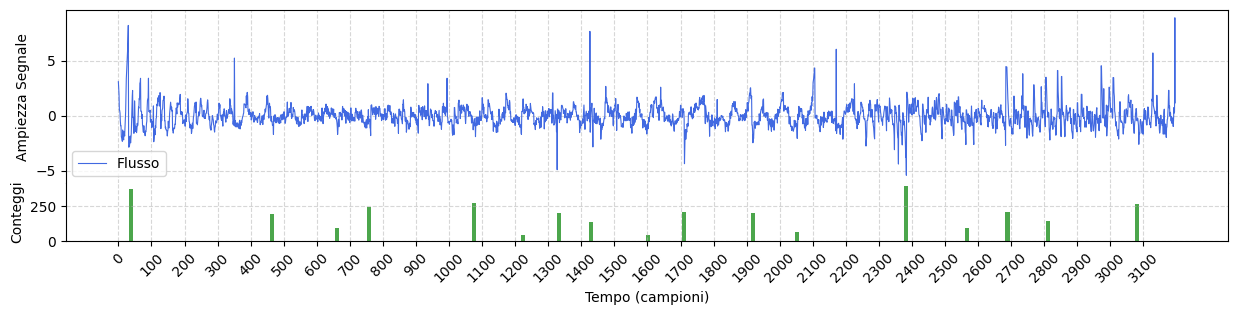

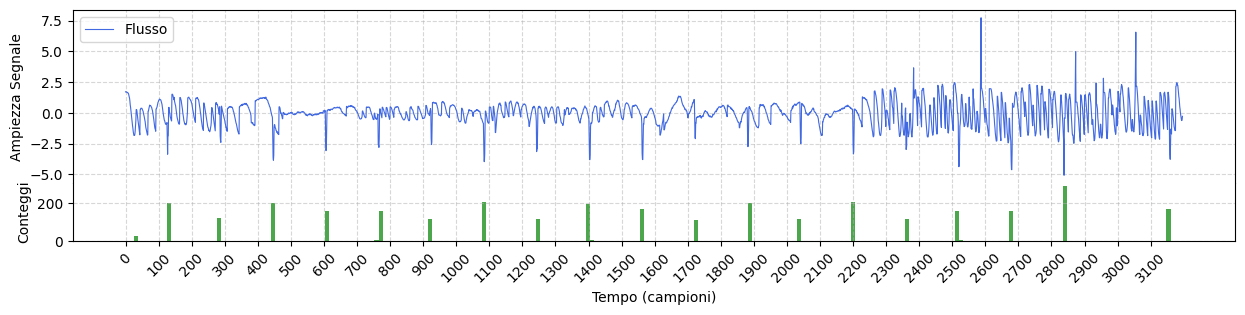

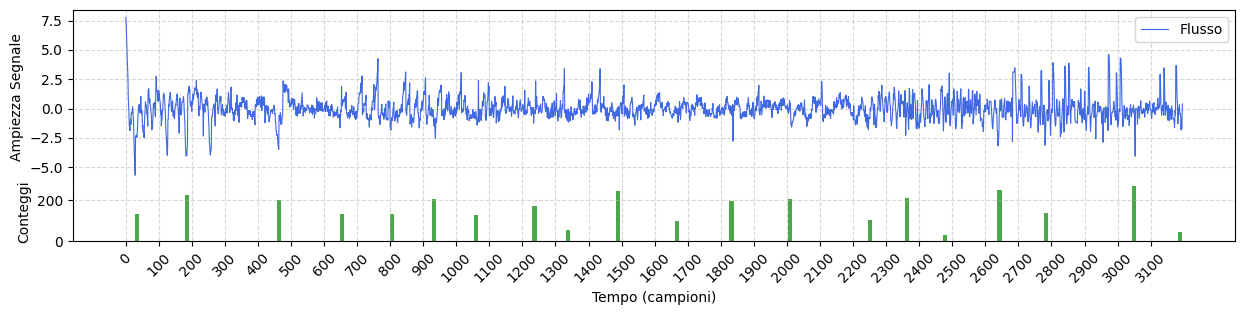

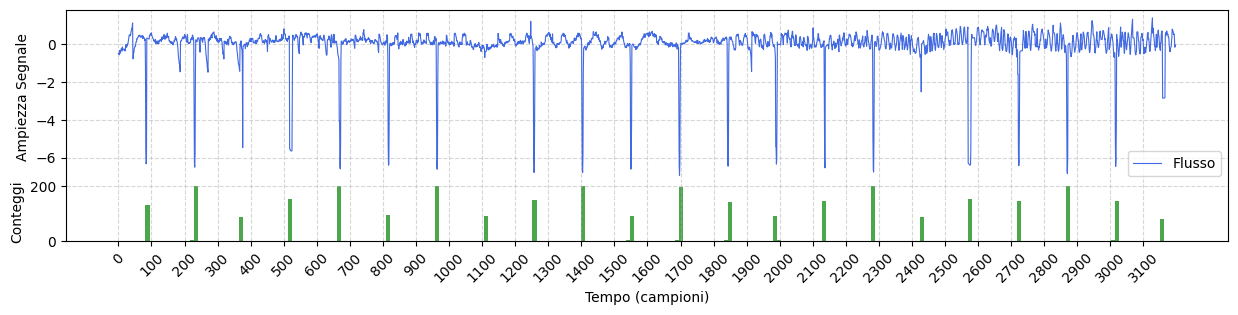

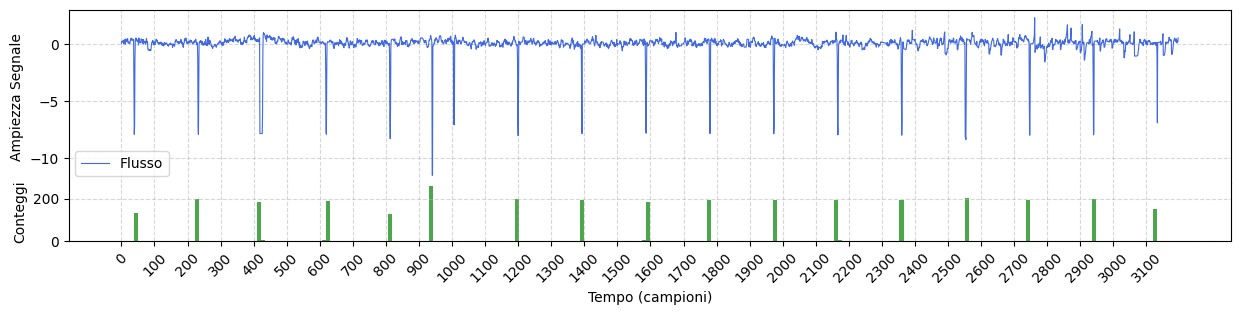

In [ ]:
    #Stampiamo nuovamente i grafici per fare confronti diretti
    for i in range(5):#(segnale_pulito2.shape[0]):
            fig, (ax_top, ax_bot) = plt.subplots(
                2, 1, figsize=(15, 3), sharex=True,
                gridspec_kw={"height_ratios": [3, 1]}
            )
            ax_top.plot(segnale_pulito2[i], color="royalblue", lw=0.8, label="Flusso")
            ax_top.set_ylabel("Ampiezza Segnale")
            ax_top.grid(True, ls="--", alpha=0.5)
            ax_top.legend()
            ax_top.spines["bottom"].set_visible(False)

            num, bins = np.histogram(indici_min[i], bins=250)
            centri    = (bins[:-1] + bins[1:]) / 2
            width_bar = bins[1] - bins[0]
            ax_bot.bar(centri, num, width=width_bar, color="green", alpha=0.7)
            ax_bot.set_ylabel("Conteggi")
            ax_bot.set_xlabel("Tempo (campioni)")
            ax_bot.set_xticks(np.arange(0,len(segnale_pulito2[0]),100))
            ax_bot.tick_params(axis='x', rotation=45)
            ax_bot.grid(True, ls="--", alpha=0.5)
            ax_bot.spines["top"].set_visible(False)
            fig.subplots_adjust(hspace=0.0)
            plt.show()


In [ ]:
print("\n----------caso0----------")

lenght_depth(segnale_pulito2, indici_min,n_counts_min=2, tolerance=30);



----------caso0----------
Inizio min_con_freq


100%|██████████| 5/5 [00:00<00:00,  5.64it/s]


curva 0: 5 periodicità trovate
  Δt = 1188  inizio = 31  posizioni: [  31. 1219. 2383.]
  Δt = 1404  inizio = 31  posizioni: [  31. 1435. 2817.]
  Δt = 1681  inizio = 31  posizioni: [  31. 1712.]
  Δt = 2022  inizio = 31  posizioni: [  31. 2053.]
  Δt = 935  inizio = 663  posizioni: [ 663. 1598. 2563.]
curva 1: 2 periodicità trovate
  Δt = 2175  inizio = 26  posizioni: [  26. 2201.]
  Δt = 2493  inizio = 26  posizioni: [  26. 2519.]
curva 2: 14 periodicità trovate
  Δt = 1310  inizio = 29  posizioni: [  29. 1339. 2638.]
  Δt = 1641  inizio = 29  posizioni: [  29. 1670.]
  Δt = 1808  inizio = 29  posizioni: [  29. 1837.]
  Δt = 2217  inizio = 29  posizioni: [  29. 2246.]
  Δt = 3024  inizio = 29  posizioni: [  29. 3053.]
  Δt = 3163  inizio = 29  posizioni: [  29. 3192.]
  Δt = 1156  inizio = 183  posizioni: [ 183. 1339. 2473.]
  Δt = 2870  inizio = 183  posizioni: [ 183. 3053.]
  Δt = 1896  inizio = 463  posizioni: [ 463. 2359.]
  Δt = 1598  inizio = 648  posizioni: [ 648. 2246.]
  Δt 

100%|██████████| 5/5 [00:00<00:00, 404.39it/s]


---------------Curva 0----------------
depth 4.62, n_minimi 3, periodo 1188
depth 4.75, n_minimi 3, periodo 1404
depth 7.07, n_minimi 2, periodo 1681
depth 5.33, n_minimi 2, periodo 2022
depth 1.20, n_minimi 3, periodo 935

---------------Curva 1----------------
depth 1.53, n_minimi 2, periodo 2175
depth 1.79, n_minimi 2, periodo 2493

---------------Curva 2----------------
depth 2.23, n_minimi 3, periodo 1310
depth 2.28, n_minimi 2, periodo 1641
depth 3.13, n_minimi 2, periodo 1808
depth 2.10, n_minimi 2, periodo 2217
depth 3.66, n_minimi 2, periodo 3024
depth 2.53, n_minimi 2, periodo 3163
depth 2.03, n_minimi 3, periodo 1156
depth 3.35, n_minimi 2, periodo 2870
depth 1.70, n_minimi 2, periodo 1896
depth 0.87, n_minimi 2, periodo 1598
depth 1.31, n_minimi 2, periodo 2544
depth 1.87, n_minimi 2, periodo 1422
depth 1.27, n_minimi 2, periodo 2255
depth 1.30, n_minimi 2, periodo 1958

---------------Curva 3----------------
depth 4.87, n_minimi 22, periodo 147

---------------Curva 4----

In questo caso, dall’analisi grafica si osserva che i minimi potenzialmente associabili al transito di un esopianeta presentano le seguenti caratteristiche:
* Curva 0: i minimi rilevanti identificati a partire dall'istante 31 si riducono esclusivamente all'insieme \([31, 1219, 2383]\). Sebbene l'evento a 1219 mostri un'ampiezza estremamente ridotta, il minimo a 2383 presenta un'elevata probabilità di essere generato dal transito di un esopianeta. Al contrario, il primo minimo a 31 è immerso in una regione ad alto rumore, il che ne rende incerta l'attribuzione causale.
* Curva 1: entrambi i minimi a 2175 e 2493 appaiono plausibili e in perfetto accordo di periodicità con i precedenti; tuttavia, nessuno degli eventi intermedi lungo l'intervallo temporale viene identificato dall'algoritmo. Inoltre, il minimo registrato a 26 presenta un'ampiezza comparabile al rumore di fondo, risultando di conseguenza inaffidabile come punto di riferimento.
* Curva 2: tutti i minimi mostrati in figura vengono correttamente rilevati, ma l'algoritmo li interpreta erroneamente come passaggi di esopianeti distinti. Dal confronto visivo con il grafico emerge chiaramente una genesi comune per tutti gli eventi, un'evidenza supportata in particolare dall'omogeneità dei loro valori di ampiezza (depth).
* Curva 3: tutti i minimi vengono identificati in modo corretto e coerente.
* Curva 4: analogamente a quanto riscontrato nei casi precedenti, si evidenzia una netta difficoltà dell'algoritmo nel rilevare e ricostruire la palese periodicità dei minimi di luminosità.


In [ ]:
print("\n----------caso1----------")

lenght_depth(segnale_pulito2, indici_min,n_counts_min=2, tolerance=50);



----------caso1----------
Inizio min_con_freq


100%|██████████| 5/5 [00:00<00:00, 11915.64it/s]


curva 0: 4 periodicità trovate
  Δt = 1188  inizio = 31  posizioni: [  31. 1219. 2383.]
  Δt = 1404  inizio = 31  posizioni: [  31. 1435. 2817.]
  Δt = 1681  inizio = 31  posizioni: [  31. 1712.]
  Δt = 2022  inizio = 31  posizioni: [  31. 2053.]
curva 1: 1 periodicità trovate
  Δt = 2072  inizio = 766  posizioni: [ 766. 2838.]
curva 2: 11 periodicità trovate
  Δt = 1310  inizio = 29  posizioni: [  29. 1339. 2638.]
  Δt = 1641  inizio = 29  posizioni: [  29. 1670.]
  Δt = 2217  inizio = 29  posizioni: [  29. 2246.]
  Δt = 3024  inizio = 29  posizioni: [  29. 3053.]
  Δt = 3163  inizio = 29  posizioni: [  29. 3192.]
  Δt = 1156  inizio = 183  posizioni: [ 183. 1339. 2473.]
  Δt = 2063  inizio = 183  posizioni: [ 183. 2246.]
  Δt = 2870  inizio = 183  posizioni: [ 183. 3053.]
  Δt = 1783  inizio = 463  posizioni: [ 463. 2246.]
  Δt = 845  inizio = 648  posizioni: [ 648. 1493. 2359. 3192.]
  Δt = 2405  inizio = 648  posizioni: [ 648. 3053.]
curva 3: 1 periodicità trovate
  Δt = 147  inizi

100%|██████████| 5/5 [00:00<00:00, 496.04it/s]


---------------Curva 0----------------
depth 4.62, n_minimi 3, periodo 1188
depth 4.75, n_minimi 3, periodo 1404
depth 7.07, n_minimi 2, periodo 1681
depth 5.33, n_minimi 2, periodo 2022

---------------Curva 1----------------
depth 2.99, n_minimi 2, periodo 2072

---------------Curva 2----------------
depth 2.23, n_minimi 3, periodo 1310
depth 2.28, n_minimi 2, periodo 1641
depth 2.10, n_minimi 2, periodo 2217
depth 3.66, n_minimi 2, periodo 3024
depth 2.53, n_minimi 2, periodo 3163
depth 2.03, n_minimi 3, periodo 1156
depth 1.78, n_minimi 2, periodo 2063
depth 3.35, n_minimi 2, periodo 2870
depth 0.67, n_minimi 2, periodo 1783
depth 1.75, n_minimi 4, periodo 845
depth 2.43, n_minimi 2, periodo 2405

---------------Curva 3----------------
depth 4.89, n_minimi 22, periodo 147

---------------Curva 4----------------
depth 8.92, n_minimi 2, periodo 1226


Questo scenario risulta equivalente al precedente, evidenziando analoghe difficoltà nell'identificazione della periodicità dei minimi.Il criterio di selezione impone che, affinché una sequenza periodica venga salvata, la distanza temporale tra un minimo e i successivi non debba coincidere con un intervallo già registrato in precedenza. Di conseguenza, il mancato salvataggio di alcune coppie di minimi implica che la loro distanza relativa sia pari (entro la tolleranza) a un intervallo già memorizzato. Si ricordi inoltre che in questo dataset si ha a che fare con misure correlate tra loro e che non sono i.i.d..Il limite fondamentale di questo approccio risiede nella propagazione dell'errore rispetto al punto di riferimento iniziale. Se un minimo si verifica con uno scostamento di 40 punti oltre il valore atteso e il minimo successivo presenta un ritardo analogo di altri 40 punti rispetto al precedente, quest'ultimo si troverà distanziato di ben 80 punti rispetto alla previsione teorica calcolata rigidamente a partire dall'origine della traiettoria.Per ovviare a questo problema, la condizione di tolleranza non dovrebbe essere calcolata in modo assoluto rispetto all'istante iniziale, bensì in modo relativo rispetto alla posizione dell'ultimo evento validato. Tale approccio è giustificato dalla natura stessa dei dati, i quali presentano una forte correlazione temporale e non possono essere considerati come variabili indipendenti e identicamente distribuite (i.i.d.).

In [ ]:
print("\n----------caso2----------")

lenght_depth(segnale_pulito2, indici_min,n_counts_min=3, tolerance=105);



----------caso2----------
Inizio min_con_freq


100%|██████████| 5/5 [00:00<00:00, 11997.44it/s]


curva 0: 4 periodicità trovate
  Δt = 1049  inizio = 31  posizioni: [  31. 1080. 2053. 3086.]
  Δt = 1567  inizio = 31  posizioni: [  31. 1598. 3086.]
  Δt = 2352  inizio = 31  posizioni: [  31. 2383.]
  Δt = 2786  inizio = 31  posizioni: [  31. 2817.]
curva 1: 6 periodicità trovate
  Δt = 262  inizio = 26  posizioni: [  26.  288.  606.  925. 1243. 1564. 1882. 2201. 2519. 2838. 3159.]
  Δt = 899  inizio = 26  posizioni: [  26.  925. 1882. 2838.]
  Δt = 2493  inizio = 26  posizioni: [  26. 2519.]
  Δt = 639  inizio = 127  posizioni: [ 127.  766. 1404. 2042. 2680.]
  Δt = 2233  inizio = 127  posizioni: [ 127. 2360.]
  Δt = 3032  inizio = 127  posizioni: [ 127. 3159.]
curva 3: 1 periodicità trovate
  Δt = 147  inizio = 84  posizioni: [  84.  231.  376.  522.  671.  817.  964. 1108. 1257. 1404. 1550. 1697.
 1844. 1990. 2137. 2284. 2428. 2575. 2723. 2870. 3016. 3158.]
curva 4: 1 periodicità trovate
  Δt = 194  inizio = 39  posizioni: [  39.  233.  421.  620.  813.  941. 1200. 1393. 1587. 17

100%|██████████| 5/5 [00:00<00:00, 256.21it/s]


---------------Curva 0----------------
depth 3.57, n_minimi 4, periodo 1049
depth 4.18, n_minimi 3, periodo 1567

---------------Curva 1----------------
depth 2.66, n_minimi 11, periodo 262
depth 2.43, n_minimi 4, periodo 899
depth 2.27, n_minimi 5, periodo 639

---------------Curva 2----------------

---------------Curva 3----------------
depth 4.89, n_minimi 22, periodo 147

---------------Curva 4----------------
depth 7.24, n_minimi 17, periodo 194


Come atteso aumentando l'ampiezza di tolleranza in curva4 tutti i minimi vengono raggruppati nel medesimo insieme

In [ ]:
print("\n----------caso3----------")
lenght_depth(segnale_pulito2, indici_min,n_counts_min=3, tolerance=200);


----------caso3----------
Inizio min_con_freq


100%|██████████| 5/5 [00:00<00:00, 14463.12it/s]


curva 0: 1 periodicità trovate
  Δt = 438  inizio = 31  posizioni: [  31.  469.  735. 1080. 1475. 1919. 2383. 2817. 3086.]
curva 1: 1 periodicità trovate
  Δt = 331  inizio = 116  posizioni: [ 116.  447.  687. 1085. 1477. 1882. 2258. 2520. 2838. 3159.]
curva 2: 1 periodicità trovate
  Δt = 337  inizio = 126  posizioni: [ 126.  463.  884. 1259. 1670. 2014. 2321. 2688. 3072.]
curva 3: 2 periodicità trovate
  Δt = 438  inizio = 84  posizioni: [  84.  522.  917. 1451. 1901. 2284. 2723. 3066.]
  Δt = 643  inizio = 275  posizioni: [ 275.  917. 1451. 2137. 2723.]
curva 4: 1 periodicità trovate
  Δt = 380  inizio = 39  posizioni: [  39.  419.  899. 1296. 1587. 1973. 2360. 2747. 3133.]
Inizio lenght_depth


100%|██████████| 5/5 [00:00<00:00, 422.76it/s]


---------------Curva 0----------------
depth 2.52, n_minimi 9, periodo 438

---------------Curva 1----------------
depth 2.06, n_minimi 10, periodo 331

---------------Curva 2----------------
depth 1.16, n_minimi 9, periodo 337

---------------Curva 3----------------
depth 2.61, n_minimi 8, periodo 438
depth 2.35, n_minimi 5, periodo 643

---------------Curva 4----------------
depth 5.70, n_minimi 9, periodo 380


Incrementando ulteriormente il valore di tolerance, si osserva che i minimi della Curva 1 vengono correttamente aggregati in un unico gruppo; tuttavia, come effetto collaterale, i cluster precedentemente stabili delle Curve 3 e 4 subiscono una frammentazione.Il tentativo di sintonizzare i parametri per soddisfare un'intuizione puramente visiva ha quindi condotto ai risultati attesi in un sottoinsieme di dati, falsandone e peggiorandone però degli altri. Questo comportamento evidenzia un problema di overfitting empirico, dimostrando come una singola soglia di tolleranza globale non sia sufficiente a descrivere l'eterogeneità di tutte le traiettorie e come sia invece necessario un approccio adattivo o basato su metriche statistiche locali.

#Parte 3

Trovate le profondità dei minimi si potrebbe estrarre il raggio del pianeta conoscendo il raggio della stella. Ciò nonostante questa operazione non è stata fatta a causa dell'assenza di riferimenti a quali stelle corrispondano le osservazioni dei flussi.